# 06b — notochord / floor plate subclustering

**Feeds:** ED Fig 7

**Position in the chain:** run the numbered stages in order

Ported from the original analysis. Saved cell outputs are from the original run, and paths in them appear as `<analysis-root>/...`.

**Changes from the original notebook**, so that it runs from this repository:
1. Paths. The first code cell finds the repository from any working directory inside it; the original required a directory named `trunk_main_dev`. `PROJECT_ROOT`, which was the analysis directory, is now `scrnaseq/chain_inputs/`, the shipped files that no notebook writes, in the same layout. `DEV_ROOT`, under which the notebook writes, is `$SCRNASEQ_RESULTS_ROOT/trunk_main_dev/` (default `scrnaseq/output/trunk_main_dev/`) instead of the analysis directory's `trunk_main_dev/`.

No other line of code was changed.


# 06b - Notochord / Floor Plate Subclustering

Depends on: `01_preprocessing` and `02_trunk_main` artifacts.

This notebook is written as the validation stage for the original coarse `Notochord / Floor Plate` population from active `02`.
It reconstructs that original parent pool as the union of current `Notochord` and `Floor Plate` labels, applies a compact manual axial validation panel,
and asks whether subclustering recovers the exact floor plate versus notochord division used in `02`.
Manual floor plate seed cells are treated strictly as the validation target for this reconstruction rather than as an input to define the split.


In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'trunk_morph_ref').exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate the repository root containing src/trunk_morph_ref/')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.trunk_morph_ref.paths import chain_inputs_root

# Inputs that no notebook writes: scrnaseq/chain_inputs/, laid out as the original analysis directory.
PROJECT_ROOT = chain_inputs_root(REPO_ROOT)

import os
os.chdir(REPO_ROOT)

## Setup and Imports

In [ ]:
import json
import re

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from cmcrameri.cm import batlow
from scipy.sparse import save_npz
from sklearn.linear_model import LogisticRegression

from src.trunk_morph_ref.cell_ordering import ordered_cells_by_cluster_clustermap
from src.trunk_morph_ref.paths import init_output_paths, scrnaseq_results_root
from src.trunk_morph_ref.plotting import (
    bold_selected_heatmap_yticklabels,
    hide_heatmap_axes_and_colorbar,
    keep_only_selected_heatmap_yticklabels,
    plot_empty_heatmap_axes,
)
from src.trunk_morph_ref.preprocessing import (
    assert_gene_id_index,
    ensure_gene_id_index,
    filter_genes_sparse_safe as filter_genes,
    install_scanpy_symbol_defaults,
    normalize_unit_variance_sparse_safe as normalize_unit_variance,
    resolve_symbols,
    var_names_to_symbols,
)
from src.trunk_morph_ref.pipeline_io import (
    load_h5ad,
    load_npy,
    save_h5ad,
    save_json,
    save_pickle,
    stage_dir,
)

# Outputs: $SCRNASEQ_RESULTS_ROOT (default scrnaseq/output/), under trunk_main_dev/ as in the original.
DEV_ROOT = scrnaseq_results_root(REPO_ROOT) / "trunk_main_dev"
RESULTS_DIR, MANUSCRIPT_FIG_DIR, EXTENDED_FIG_DIR = init_output_paths(DEV_ROOT)
install_scanpy_symbol_defaults(sc)
plt.rcParams['svg.fonttype'] = 'none'
NOTEBOOK_DPI = 110

/opt/anaconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version


/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3

In [ ]:
pre_path = stage_dir(RESULTS_DIR, '01_preprocessing')
trunk_path = stage_dir(RESULTS_DIR, '02_trunk_main')
stage_path = stage_dir(RESULTS_DIR, '06b_notochord_floor_plate_subclustering')
figures_dir = stage_path / 'figures'
tables_dir = stage_path / 'tables'
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

adata_morph_raw = load_h5ad(pre_path / 'adata_morph_raw.h5ad')
adata_morph_with_clusters = load_h5ad(trunk_path / 'adata_morph_with_clusters.h5ad')

for _adata in [adata_morph_raw, adata_morph_with_clusters]:
    ensure_gene_id_index(_adata)
    assert_gene_id_index(_adata)

print('Loaded 01_preprocessing and 02_trunk_main intermediates')

Loaded 01_preprocessing and 02_trunk_main intermediates


## Marker Definitions and Helpers

In [ ]:
FP_POSITIVE_MARKERS = ['FOXA2', 'NKX2-8', 'LINC00261', 'PHOX2B', 'PTCH1']
FP_CONTEXT_MARKERS = ['RNF220']
NOTOCHORD_COUNTER_MARKERS = ['PTPRM', 'NOTO', 'TFF3', 'FOXA1', 'SHH', 'TBXT']
MANUAL_VALIDATION_PANEL_GENES = FP_POSITIVE_MARKERS + FP_CONTEXT_MARKERS + NOTOCHORD_COUNTER_MARKERS
MANUAL_MARKER_HEATMAP_MARKERS = ['FOXA2', 'SOX2', 'FGFBP3', 'PTCH1', 'RNF220', 'NKX2-8', 'SYNCRIP', 'ALCAM', 'SLIT2', 'IGFBP5', 'NOTO', 'LMX1A', 'TFF3', 'SHH', 'TBXT']
MANUAL_MARKER_HEATMAP_BOLD = ['FOXA2', 'SOX2', 'NKX2-8', 'NOTO', 'SHH', 'TBXT']
DISPLAY_HEATMAP_MARKERS = MANUAL_MARKER_HEATMAP_MARKERS
DISPLAY_HEATMAP_BOLD = MANUAL_MARKER_HEATMAP_BOLD
PROMOTED_KEY_HEATMAP_BOLD = ['FOXA2', 'NKX2-8', 'RNF220', 'PTCH1', 'NOTO', 'SHH', 'TBXT', 'TFF3']

SCAN_RESOLUTIONS = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
LABEL_KEY = 'leiden_morph_axial'
RAW_LABEL_KEY = 'leiden_morph_axial_raw'
STAGE_ID = '06b_notochord_floor_plate_subclustering'
minimum_reads = 5000
axial_clusters = ['Floor Plate', 'Notochord']

manual_floor_plate_seed_cell_ids = [
    'GGTGATTAGTAGACAT-1',
    'ACATTTCTCGAGAAGC-1',
    'AAGATAGAGAATACAC-1',
    'AACCTGACAAGTATCC-1',
    'ACCTGAAGTATACGGG-1',
    'CCGGACATCTTACTGT-1',
    'GGGAGATGTCTGCATA-1',
    'ACTGTCCCACTGTCGG-1',
    'ATACTTCTCTCAGGCG-1',
    'TCACTATGTTAGGCCC-1',
    'GTGAGCCTCTTGTTAC-1',
    'TTCCGTGAGGAACGCT-1',
    'TTGGATGGTCTGCAAT-1',
    'CACGGGTGTCCACAGC-1',
    'AGATCGTTCGAAGTGG-1',
    'CGATGCGCACTGGAAG-1',
    'CAGTTAGGTTAAACAG-1',
    'GAAACCTCAAATGAAC-1',
    'GTTACGATCCATACTT-1',
]

genes_cellcycle = [
    'MKI67', 'CENPE', 'SGO2', 'KIF14', 'PIF1', 'NDC80', 'CDCA8', 'PLK1', 'AURKA', 'UBE2C',
    'ASPM', 'TOP2A', 'TPX2', 'NUSAP1', 'CDC20', 'CKS2', 'KPNA2', 'TUBB4B', 'DLGAP5', 'BIRC5',
    'HMMR', 'CCNB1', 'ARL6IP1', 'PTTG1', 'UBE2S', 'DUT', 'HELLS', 'CLSPN', 'RRM2', 'PCLAF',
    'TYMS', 'KIF18B', 'SMC4', 'HIST1H4C', 'DIAPH3', 'RFC3', 'MIR924HG', 'MIS18BP1', 'TUBA1C', 'CDK1',
    'CENPA', 'KIF11', 'ECT2', 'KNL1', 'NEK2', 'CEP55', 'PSRC1', 'CDCA3', 'CCNA2', 'GTSE1',
    'CENPF', 'CKS1B', 'MELK', 'CDCA5', 'MCM4', 'HIST1H1E', 'BRCA2', 'TRIM66', 'C1orf112', 'POLD3',
    'KIF23', 'CDKAL1', 'RAD51AP1', 'RANBP1', 'CDCA2', 'CAND2', 'EIF5A', 'SRSF2', 'GINS1', 'GINS2',
    'ncAPG2', 'CCND1', 'ATAD2', 'UBE2T', 'CENPK', 'LAPTM4B', 'CCND2', 'MED13', 'ZNF37A', 'PTPN14',
    'ncAPG', 'TTK', 'KIF4A', 'KIF18A', 'CDKN3', 'CEP70', 'BRIP1', 'SPC25', 'KIFC1', 'NSD2',
    'BUB1', 'BUB1B', 'ANP32E', 'HMGB3', 'PCNA', 'CENPP', 'CCT5', 'KIF15', 'CSRP2', 'ORC6', 'HMGB2',
]

def expr_vector_by_symbol(adata, symbol):
    gene_ids = resolve_symbols(adata, [symbol], strict=False, allow_missing=True)
    if not gene_ids:
        return None
    x = adata[:, gene_ids[0]].X
    if hasattr(x, 'toarray'):
        x = x.toarray()
    return np.asarray(x).reshape(-1)

def cluster_marker_summary(adata_expr, cluster_key, marker_symbols, marker_cache=None):
    if marker_cache is None:
        marker_cache = {symbol: expr_vector_by_symbol(adata_expr, symbol) for symbol in marker_symbols}
    rows = []
    categories = list(adata_expr.obs[cluster_key].cat.categories)
    for cluster in categories:
        mask = (adata_expr.obs[cluster_key] == cluster).to_numpy()
        row = {'cluster': str(cluster), 'n_cells': int(mask.sum())}
        for symbol in marker_symbols:
            values = marker_cache.get(symbol)
            if values is None:
                row[f'{symbol}_mean'] = np.nan
                row[f'{symbol}_pct_gt1'] = np.nan
            else:
                row[f'{symbol}_mean'] = float(values[mask].mean()) if mask.sum() else np.nan
                row[f'{symbol}_pct_gt1'] = float((values[mask] > 1).mean()) if mask.sum() else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

def cluster_seed_summary(adata_expr, cluster_key, seed_col='manual_floor_plate_seed'):
    rows = []
    categories = list(adata_expr.obs[cluster_key].cat.categories)
    seeds = adata_expr.obs[seed_col].astype(bool).to_numpy()
    n_total_seeds = int(seeds.sum())
    for cluster in categories:
        mask = (adata_expr.obs[cluster_key] == cluster).to_numpy()
        n_cells = int(mask.sum())
        n_seed = int(seeds[mask].sum())
        rows.append({
            'cluster': str(cluster),
            'n_cells': n_cells,
            'n_seed_cells': n_seed,
            'seed_fraction_within_cluster': float(n_seed / n_cells) if n_cells else np.nan,
            'cluster_capture_of_all_seed_cells': float(n_seed / n_total_seeds) if n_total_seeds else np.nan,
        })
    return pd.DataFrame(rows)

def floor_plate_score(marker_summary_df):
    return (
        marker_summary_df[[f'{g}_mean' for g in FP_POSITIVE_MARKERS]].fillna(0).sum(axis=1)
        + 0.5 * marker_summary_df[[f'{g}_mean' for g in FP_CONTEXT_MARKERS]].fillna(0).sum(axis=1)
        - marker_summary_df[[f'{g}_mean' for g in NOTOCHORD_COUNTER_MARKERS]].fillna(0).sum(axis=1)
    )


## Axial Midline Reconstruction

In [ ]:
adata_morph_axial = adata_morph_raw.copy()
sc.pp.filter_cells(adata_morph_axial, min_counts=minimum_reads)
sc.pp.downsample_counts(
    adata_morph_axial,
    counts_per_cell=minimum_reads,
    replace=True,
    random_state=0,
)

adata_morph_axial.obs['leiden_morph'] = adata_morph_with_clusters.obs['leiden_morph'].reindex(
    adata_morph_axial.obs_names
)
missing_cluster_labels = int(adata_morph_axial.obs['leiden_morph'].isna().sum())
if missing_cluster_labels:
    print(
        f'Dropping {missing_cluster_labels} cells not present in adata_morph_with_clusters before coarse-cluster subsetting.'
    )
    adata_morph_axial = adata_morph_axial[adata_morph_axial.obs['leiden_morph'].notna()].copy()

adata_morph_axial = adata_morph_axial[
    adata_morph_axial.obs['leiden_morph'].isin(axial_clusters).values
].copy()
adata_morph_axial.obs['manual_floor_plate_seed'] = adata_morph_axial.obs_names.isin(manual_floor_plate_seed_cell_ids)

sc.pp.log1p(adata_morph_axial)

adata_morph_axial_filtered = filter_genes(
    adata_morph_axial,
    mean_cutoff=0.05,
    std_cutoff=0.05,
)
adata_morph_axial_filtered = normalize_unit_variance(adata_morph_axial_filtered)

print('Current coarse labels used to reconstruct the axial pool:')
display(adata_morph_axial.obs['leiden_morph'].value_counts().to_frame('n_cells'))
print(f"Manual floor plate seed cells present: {int(adata_morph_axial.obs['manual_floor_plate_seed'].sum())}")
print(
    f'{adata_morph_axial_filtered.n_obs} cells after pre-processing\n'
    f'{adata_morph_axial_filtered.n_vars} genes after preprocessing'
)

Dropping 44 cells not present in adata_morph_with_clusters before coarse-cluster subsetting.
8859 genes after filtering
Current coarse labels used to reconstruct the axial pool:


              n_cells
leiden_morph         
Notochord          30
Floor Plate        19

Manual floor plate seed cells present: 19
49 cells after pre-processing
8859 genes after preprocessing


## Save Reconstructed Axial Parent Inputs


In [ ]:
for _adata in [adata_morph_axial, adata_morph_axial_filtered]:
    assert_gene_id_index(_adata)

save_h5ad(adata_morph_axial, stage_path / 'adata_morph_notochord_floor_plate_.h5ad')
save_h5ad(adata_morph_axial_filtered, stage_path / 'adata_morph_notochord_floor_plate_filtered_.h5ad')

save_json(manual_floor_plate_seed_cell_ids, stage_path / 'manual_floor_plate_seed_cell_ids.json')
save_json(
    {
        'stage': STAGE_ID,
        'subset_clusters': axial_clusters,
        'subset_note': 'Reconstructed original coarse axial pool as union of current Floor Plate and Notochord labels from active 02.',
        'minimum_reads': minimum_reads,
        'manual_floor_plate_seed_cell_count': int(adata_morph_axial.obs['manual_floor_plate_seed'].sum()),
        'n_cells_input': int(adata_morph_axial.n_obs),
        'n_genes_input': int(adata_morph_axial.n_vars),
        'n_cells_after_preprocessing': int(adata_morph_axial_filtered.n_obs),
        'n_genes_after_preprocessing': int(adata_morph_axial_filtered.n_vars),
        'source_counts': {str(k): int(v) for k, v in adata_morph_axial.obs['source'].value_counts().items()},
        'reconstructed_coarse_label_counts': {str(k): int(v) for k, v in adata_morph_axial.obs['leiden_morph'].astype(str).value_counts().items()},
        'status': 'ready_for_manual_panel_validation',
        'manual_validation_gene_panel': list(dict.fromkeys(MANUAL_VALIDATION_PANEL_GENES)),
        'correlation_pruning': False,
    },
    stage_path / 'pre_panel_input_meta.json',
)

print(f'Saved reconstructed axial parent inputs to {stage_path}')
print(f"Manual floor plate seed cells available for validation: {int(adata_morph_axial.obs['manual_floor_plate_seed'].sum())}")


Saved pre-SMD stage outputs to <analysis-root>/trunk_main_dev/results/intermediates/06b_notochord_floor_plate_subclustering
Canonical SMD input: <analysis-root>/trunk_main_dev/results/intermediates/06b_notochord_floor_plate_subclustering/trunk_morph_notochord_floor_plate__smd_input.npz
Recommended n_sub ~= 39


## Build the Manual Axial Validation Panel


  run_id n_sub trials kmax k_prior_min  n_genes_z_gt_2  n_genes_z_gt_10  \
0    001    39    100   30           4              14                3   

        max_z  
0  111.133103  

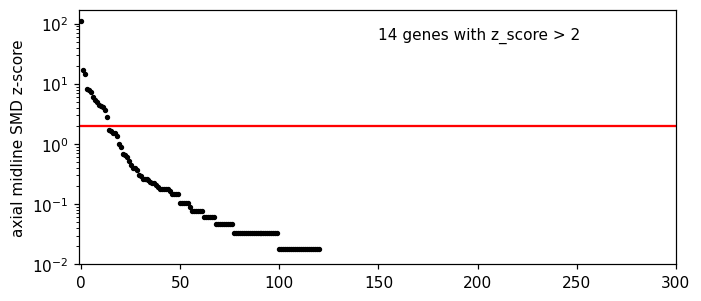

In [ ]:
manual_validation_panel_genes = list(dict.fromkeys(MANUAL_VALIDATION_PANEL_GENES))
panel_role_map = {gene: 'floor_plate_positive' for gene in FP_POSITIVE_MARKERS}
panel_role_map.update({gene: 'floor_plate_context' for gene in FP_CONTEXT_MARKERS})
panel_role_map.update({gene: 'notochord_counter_marker' for gene in NOTOCHORD_COUNTER_MARKERS})

manual_panel_summary = pd.DataFrame(
    {
        'gene_symbol': manual_validation_panel_genes,
        'panel_role': [panel_role_map[g] for g in manual_validation_panel_genes],
    }
)
save_pickle(manual_panel_summary, stage_path / 'trunk_morph_notochord_floor_plate_manual_panel_genes.pkl')
manual_panel_summary.to_csv(stage_path / 'trunk_morph_notochord_floor_plate_manual_panel_genes.csv', index=False)
display(manual_panel_summary)


In [ ]:
adata_morph_axial_ = adata_morph_axial.copy()
adata_morph_axial_filtered_ = adata_morph_axial_filtered.copy()

manual_panel_genes = list(dict.fromkeys(MANUAL_VALIDATION_PANEL_GENES))
manual_panel_gene_ids = list(
    dict.fromkeys(
        resolve_symbols(adata_morph_axial_, manual_panel_genes, strict=False, allow_missing=True)
    )
)
cellcycle_gene_ids = set(resolve_symbols(adata_morph_axial_, genes_cellcycle, strict=False, allow_missing=True))
selected_gene_ids = [g for g in manual_panel_gene_ids if g not in cellcycle_gene_ids]

if not selected_gene_ids:
    raise ValueError('No 06b manual validation-panel genes survived cell-cycle exclusion.')

panel_gene_table = pd.DataFrame({'gene_ids': selected_gene_ids})
panel_gene_table['gene_symbol'] = panel_gene_table['gene_ids'].map(adata_morph_axial_.var['gene_symbol'].to_dict())
panel_gene_table['gene_symbol_original'] = panel_gene_table['gene_ids'].map(
    adata_morph_axial_.var['gene_symbol_original'].to_dict()
)
panel_gene_table['panel_role'] = panel_gene_table['gene_symbol'].map(panel_role_map)
panel_gene_table['removed_as_cell_cycle'] = False
save_pickle(panel_gene_table, stage_path / 'trunk_morph_notochord_floor_plate_manual_panel_selection.pkl')
panel_gene_table.to_csv(stage_path / 'trunk_morph_notochord_floor_plate_manual_panel_selection.csv', index=False)
panel_gene_table.to_csv(tables_dir / 'noto_floor_plate_selected_panel_genes.csv', index=False)

adata_morph_axial_panel = adata_morph_axial_[:, selected_gene_ids].copy()
adata_morph_axial_panel = normalize_unit_variance(adata_morph_axial_panel)

print(f'Selected {len(selected_gene_ids)} manual 06b validation-panel genes.')
display(panel_gene_table[['gene_symbol', 'panel_role']])


Selected 12 06b clustering genes after axial marker add-back.


   gene_symbol  z_score_morph_axial  manually_added_to_final_smd
0         TFF3             0.003364                         True
1       RNF220            -0.025781                         True
2         NOTO            -0.025781                         True
3         TBXT            -0.025781                         True
4          SHH            -0.025781                         True
5        PTCH1            -0.025781                         True
6       NKX2-8            -0.025781                         True
7        FOXA1            -0.025781                         True
8        PTPRM            -0.025781                         True
9    LINC00261            -0.025781                         True
10       FOXA2            -0.025781                         True
11      PHOX2B                  NaN                         True
12   LINC01409           111.133103                        False
13      MT-CO1            17.053166                        False
14        RPS2           

## Resolution Scan on the Reconstructed Axial Pool

In [ ]:
scan_marker_symbols = list(dict.fromkeys(MANUAL_VALIDATION_PANEL_GENES + DISPLAY_HEATMAP_MARKERS))
scan_marker_cache = {symbol: expr_vector_by_symbol(adata_morph_axial_, symbol) for symbol in scan_marker_symbols}

resolution_scan_rows = []
adata_morph_axial_panel_scan = adata_morph_axial_panel.copy()
sc.pp.neighbors(adata_morph_axial_panel_scan, use_rep='X')

for resolution in SCAN_RESOLUTIONS:
    adata_scan = adata_morph_axial_panel_scan.copy()
    sc.tl.leiden(
        adata_scan,
        resolution=resolution,
        random_state=0,
        key_added='leiden_morph_axial_scan',
        flavor='igraph',
        n_iterations=-1,
    )
    adata_scan_expr = adata_morph_axial_.copy()
    adata_scan_expr.obs['leiden_morph_axial_scan'] = adata_scan.obs['leiden_morph_axial_scan'].astype('category')
    marker_summary_df = cluster_marker_summary(
        adata_expr=adata_scan_expr,
        cluster_key='leiden_morph_axial_scan',
        marker_symbols=scan_marker_symbols,
        marker_cache=scan_marker_cache,
    )
    seed_summary_df = cluster_seed_summary(
        adata_expr=adata_scan_expr,
        cluster_key='leiden_morph_axial_scan',
        seed_col='manual_floor_plate_seed',
    )
    marker_summary_df = marker_summary_df.merge(seed_summary_df, on=['cluster', 'n_cells'], how='left')
    marker_summary_df['resolution'] = resolution
    marker_summary_df['n_clusters'] = int(adata_scan.obs['leiden_morph_axial_scan'].nunique())
    marker_summary_df['fp_score'] = floor_plate_score(marker_summary_df)
    resolution_scan_rows.append(marker_summary_df)

resolution_scan_df = pd.concat(resolution_scan_rows, ignore_index=True)
resolution_scan_df.to_csv(tables_dir / 'noto_floor_plate_resolution_marker_scan.csv', index=False)

resolution_scan_candidates = resolution_scan_df.loc[resolution_scan_df['n_cells'] >= 3].copy()
resolution_scan_best = (
    resolution_scan_candidates.sort_values(['resolution', 'fp_score'], ascending=[True, False])
    .groupby('resolution')
    .head(1)
    .reset_index(drop=True)
)
resolution_scan_best.to_csv(tables_dir / 'noto_floor_plate_resolution_best_clusters.csv', index=False)
display(
    resolution_scan_best[
        [
            'resolution', 'n_clusters', 'cluster', 'n_cells', 'fp_score', 'n_seed_cells',
            'seed_fraction_within_cluster', 'FOXA2_mean', 'NKX2-8_mean', 'LINC00261_mean',
            'PHOX2B_mean', 'NOTO_mean', 'TFF3_mean', 'SHH_mean',
        ]
    ]
)

/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


   resolution  n_clusters cluster  n_cells  fp_score  n_seed_cells  \
0        0.45           2       0       19  3.695281            19   
1        0.50           2       0       23  2.983290            19   
2        0.60           3       0       19  3.695281            19   
3        0.70           3       0       18  3.862066            18   
4        0.80           4       0       18  3.862066            18   
5        0.90           4       0       18  3.862066            18   
6        1.00           5       0       18  3.862066            18   

   seed_fraction_within_cluster  FOXA2_mean  NKX2-8_mean  LINC00261_mean  \
0                      1.000000    0.884556     0.456375        0.188606   
1                      0.826087    0.808623     0.377005        0.155805   
2                      1.000000    0.884556     0.456375        0.188606   
3                      1.000000    0.895190     0.481729        0.199084   
4                      1.000000    0.895190     0.481729   

In [ ]:
if resolution_scan_best.empty:
    raise ValueError('No usable raw Leiden clusters with at least 3 cells were found during the 06b resolution scan.')

ADOPTED_LEIDEN_RESOLUTION = 0.45
CHOSEN_LEIDEN_RESOLUTION = float(ADOPTED_LEIDEN_RESOLUTION)
CHOSEN_LEIDEN_REASON = (
    'Adopted manual-panel working resolution after the 06b multi-seed manual-panel scan: '
    '0.45 preserves the exact Floor Plate (19) versus Notochord (30) split in the reference seed-0 run '
    'and is the most stable two-way split around that target without introducing a persistent third cluster.'
)
print(f'Chosen 06b resolution: {CHOSEN_LEIDEN_RESOLUTION:.2f}')
print(CHOSEN_LEIDEN_REASON)


Chosen 06b resolution: 0.45
Lowest raw Leiden resolution that isolates a FOXA2-high, NKX2-8-positive, low-TFF3, low-SHH floor-plate-like cluster from the reconstructed axial parent pool.


## Chosen Axial Midline Split

In [ ]:
adata_morph_axial_panel_ = adata_morph_axial_panel.copy()
sc.pp.neighbors(adata_morph_axial_panel_, use_rep='X')
sc.tl.umap(adata_morph_axial_panel_, random_state=0)
sc.tl.leiden(
    adata_morph_axial_panel_,
    resolution=CHOSEN_LEIDEN_RESOLUTION,
    random_state=0,
    key_added=RAW_LABEL_KEY,
    flavor='igraph',
    n_iterations=-1,
)

adata_morph_axial_with_clusters = adata_morph_axial_.copy()
adata_morph_axial_with_clusters.obs[RAW_LABEL_KEY] = adata_morph_axial_panel_.obs[RAW_LABEL_KEY].astype('category')

cluster_marker_cache = {symbol: expr_vector_by_symbol(adata_morph_axial_with_clusters, symbol) for symbol in scan_marker_symbols}
raw_cluster_marker_summary = cluster_marker_summary(
    adata_expr=adata_morph_axial_with_clusters,
    cluster_key=RAW_LABEL_KEY,
    marker_symbols=scan_marker_symbols,
    marker_cache=cluster_marker_cache,
)
raw_cluster_marker_summary['fp_score'] = floor_plate_score(raw_cluster_marker_summary)
raw_cluster_seed_summary = cluster_seed_summary(
    adata_expr=adata_morph_axial_with_clusters,
    cluster_key=RAW_LABEL_KEY,
    seed_col='manual_floor_plate_seed',
)
raw_cluster_marker_summary = raw_cluster_marker_summary.merge(
    raw_cluster_seed_summary,
    on=['cluster', 'n_cells'],
    how='left',
)
raw_cluster_marker_summary = raw_cluster_marker_summary.sort_values(
    ['fp_score', 'n_cells'],
    ascending=[False, False],
).reset_index(drop=True)
raw_cluster_marker_summary.to_csv(tables_dir / 'noto_floor_plate_raw_cluster_marker_summary.csv', index=False)

eligible_fp_rows = raw_cluster_marker_summary.loc[raw_cluster_marker_summary['n_cells'] >= 3]
if eligible_fp_rows.empty:
    floor_plate_raw_cluster = str(raw_cluster_marker_summary.iloc[0]['cluster'])
else:
    floor_plate_raw_cluster = str(eligible_fp_rows.iloc[0]['cluster'])

collapsed_labels = np.where(
    adata_morph_axial_panel_.obs[RAW_LABEL_KEY].astype(str).to_numpy() == floor_plate_raw_cluster,
    'Floor Plate',
    'Notochord',
)
adata_morph_axial_panel_.obs[LABEL_KEY] = pd.Categorical(
    collapsed_labels,
    categories=['Floor Plate', 'Notochord'],
    ordered=True,
)
adata_morph_axial_with_clusters.obs[LABEL_KEY] = adata_morph_axial_panel_.obs[LABEL_KEY]

chosen_cluster_marker_summary = cluster_marker_summary(
    adata_expr=adata_morph_axial_with_clusters,
    cluster_key=LABEL_KEY,
    marker_symbols=scan_marker_symbols,
    marker_cache=cluster_marker_cache,
)
chosen_cluster_marker_summary['fp_score'] = floor_plate_score(chosen_cluster_marker_summary)
chosen_cluster_seed_summary = cluster_seed_summary(
    adata_expr=adata_morph_axial_with_clusters,
    cluster_key=LABEL_KEY,
    seed_col='manual_floor_plate_seed',
)
chosen_cluster_marker_summary = chosen_cluster_marker_summary.merge(
    chosen_cluster_seed_summary,
    on=['cluster', 'n_cells'],
    how='left',
)
chosen_cluster_marker_summary.to_csv(tables_dir / 'noto_floor_plate_chosen_cluster_marker_summary.csv', index=False)

seed_validation = pd.crosstab(
    adata_morph_axial_with_clusters.obs['manual_floor_plate_seed'].astype(str),
    adata_morph_axial_with_clusters.obs[LABEL_KEY].astype(str),
)
seed_validation.to_csv(tables_dir / 'noto_floor_plate_seed_validation.csv')

print(f'Chosen raw floor plate cluster: {floor_plate_raw_cluster}')
display(
    raw_cluster_marker_summary[
        [
            'cluster', 'n_cells', 'fp_score', 'n_seed_cells', 'seed_fraction_within_cluster',
            'cluster_capture_of_all_seed_cells', 'FOXA2_mean', 'NKX2-8_mean', 'LINC00261_mean',
            'PHOX2B_mean', 'NOTO_mean', 'TFF3_mean', 'SHH_mean',
        ]
    ]
)
display(
    chosen_cluster_marker_summary[
        [
            'cluster', 'n_cells', 'fp_score', 'n_seed_cells', 'seed_fraction_within_cluster',
            'cluster_capture_of_all_seed_cells', 'FOXA2_mean', 'NKX2-8_mean', 'LINC00261_mean',
            'PHOX2B_mean', 'NOTO_mean', 'TFF3_mean', 'SHH_mean',
        ]
    ]
)
display(seed_validation)

/opt/anaconda3/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


Chosen raw floor plate cluster: 0


  cluster  n_cells  fp_score  n_seed_cells  seed_fraction_within_cluster  \
0       0       19  3.695281            19                           1.0   
1       1       30 -2.188501             0                           0.0   

   cluster_capture_of_all_seed_cells  FOXA2_mean  NKX2-8_mean  LINC00261_mean  \
0                                1.0    0.884556     0.456375        0.188606   
1                                0.0    0.281185     0.000000        0.069315   

   PHOX2B_mean  NOTO_mean  TFF3_mean  SHH_mean  
0     0.036481   0.000000   0.036481  0.000000  
1     0.000000   0.542777   1.334781  0.345448  

       cluster  n_cells  fp_score  n_seed_cells  seed_fraction_within_cluster  \
0  Floor Plate       19  3.695281            19                           1.0   
1    Notochord       30 -2.188501             0                           0.0   

   cluster_capture_of_all_seed_cells  FOXA2_mean  NKX2-8_mean  LINC00261_mean  \
0                                1.0    0.884556     0.456375        0.188606   
1                                0.0    0.281185     0.000000        0.069315   

   PHOX2B_mean  NOTO_mean  TFF3_mean  SHH_mean  
0     0.036481   0.000000   0.036481  0.000000  
1     0.000000   0.542777   1.334781  0.345448  

leiden_morph_axial       Floor Plate  Notochord
manual_floor_plate_seed                        
False                              0         30
True                              19          0

## Axial Midline DEGs by Logistic Regression

In [ ]:
logreg_cluster_order = list(adata_morph_axial_with_clusters.obs[LABEL_KEY].cat.categories)
X_logreg = adata_morph_axial_with_clusters.X
if scipy.sparse.issparse(X_logreg):
    X_logreg = X_logreg.tocsr()
y_codes = adata_morph_axial_with_clusters.obs[LABEL_KEY].cat.codes.to_numpy()
if len(np.unique(y_codes)) < 2:
    raise ValueError(
        f"06b collapsed to a single label after raw cluster selection: {adata_morph_axial_with_clusters.obs[LABEL_KEY].astype(str).value_counts().to_dict()}"
    )

clf = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=0,
)
clf.fit(X_logreg, y_codes)

coef_map = {}
coef_direction_map = {}
if clf.coef_.shape[0] == 1 and len(logreg_cluster_order) == 2:
    positive_code = int(clf.classes_[1])
    negative_code = int(clf.classes_[0])
    coef_map[logreg_cluster_order[positive_code]] = clf.coef_[0]
    coef_map[logreg_cluster_order[negative_code]] = -clf.coef_[0]
    coef_direction_map[logreg_cluster_order[positive_code]] = 'positive_coefficients'
    coef_direction_map[logreg_cluster_order[negative_code]] = 'negative_coefficients'
else:
    for row_idx, class_code in enumerate(clf.classes_):
        coef_map[logreg_cluster_order[int(class_code)]] = clf.coef_[row_idx]
        coef_direction_map[logreg_cluster_order[int(class_code)]] = 'multinomial_one_vs_rest'

deg_name_map = {}
deg_score_map = {}
deg_direction_rows = []
for cluster_name in logreg_cluster_order:
    coef_vector = coef_map[cluster_name]
    ranked_idx = np.argsort(coef_vector)[::-1][:100]
    deg_name_map[cluster_name] = adata_morph_axial_with_clusters.var_names[ranked_idx].tolist()
    deg_score_map[cluster_name] = coef_vector[ranked_idx].astype(float).tolist()
    deg_direction_rows.append(
        {
            'cluster': cluster_name,
            'coefficient_direction': coef_direction_map[cluster_name],
        }
    )

axial_deg_names = pd.DataFrame(deg_name_map)
axial_deg_scores = pd.DataFrame(deg_score_map)
axial_deg_names.to_csv(tables_dir / 'noto_floor_plate_top100_logreg_deg_names.csv', index=False)
axial_deg_scores.to_csv(tables_dir / 'noto_floor_plate_top100_logreg_deg_scores.csv', index=False)
pd.DataFrame(deg_direction_rows).to_csv(
    tables_dir / 'noto_floor_plate_top100_logreg_deg_directions.csv',
    index=False,
)

deg_long_rows = []
for cluster_name in axial_deg_names.columns:
    for rank, (gene_id, score) in enumerate(
        zip(axial_deg_names[cluster_name], axial_deg_scores[cluster_name]),
        start=1,
    ):
        deg_long_rows.append(
            {
                'cluster': cluster_name,
                'rank': rank,
                'gene_id': str(gene_id),
                'gene_symbol': str(adata_morph_axial_with_clusters.var.loc[gene_id, 'gene_symbol']),
                'score': float(score),
            }
        )
deg_long_df = pd.DataFrame(deg_long_rows)
deg_long_df.to_csv(tables_dir / 'noto_floor_plate_top100_logreg_deg_long.csv', index=False)
display(deg_long_df.head(20))

        cluster  rank          gene_id gene_symbol     score
0   Floor Plate     1  ENSG00000281566  AL157778.1  0.031189
1   Floor Plate     2  ENSG00000141449      GREB1L  0.027743
2   Floor Plate     3  ENSG00000174721      FGFBP3  0.027503
3   Floor Plate     4  ENSG00000171843       MLLT3  0.027195
4   Floor Plate     5  ENSG00000187147      RNF220  0.025699
5   Floor Plate     6  ENSG00000179104       TMTC2  0.025453
6   Floor Plate     7  ENSG00000164946       FREM1  0.025074
7   Floor Plate     8  ENSG00000117724       CENPF  0.023956
8   Floor Plate     9  ENSG00000125798       FOXA2  0.022465
9   Floor Plate    10  ENSG00000112541      PDE10A  0.022122
10  Floor Plate    11  ENSG00000184349       EFNA5  0.020906
11  Floor Plate    12  ENSG00000233101    HOXB-AS3  0.020692
12  Floor Plate    13  ENSG00000054523       KIF1B  0.019991
13  Floor Plate    14  ENSG00000185920       PTCH1  0.019653
14  Floor Plate    15  ENSG00000008394       MGST1  0.019563
15  Floor Plate    16  E

## Axial Midline Visualizations and Heatmaps

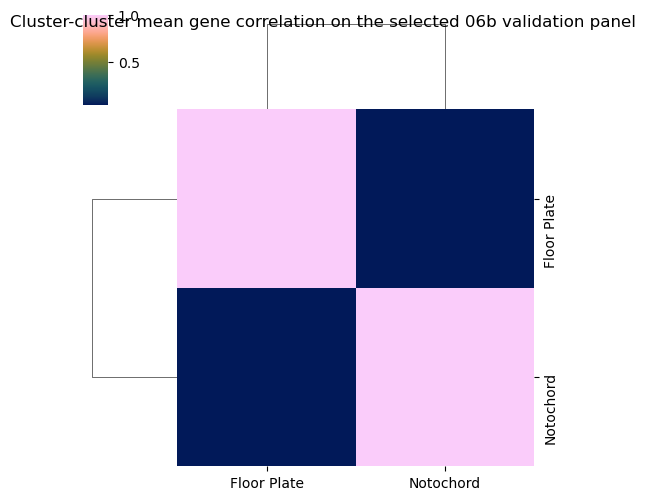

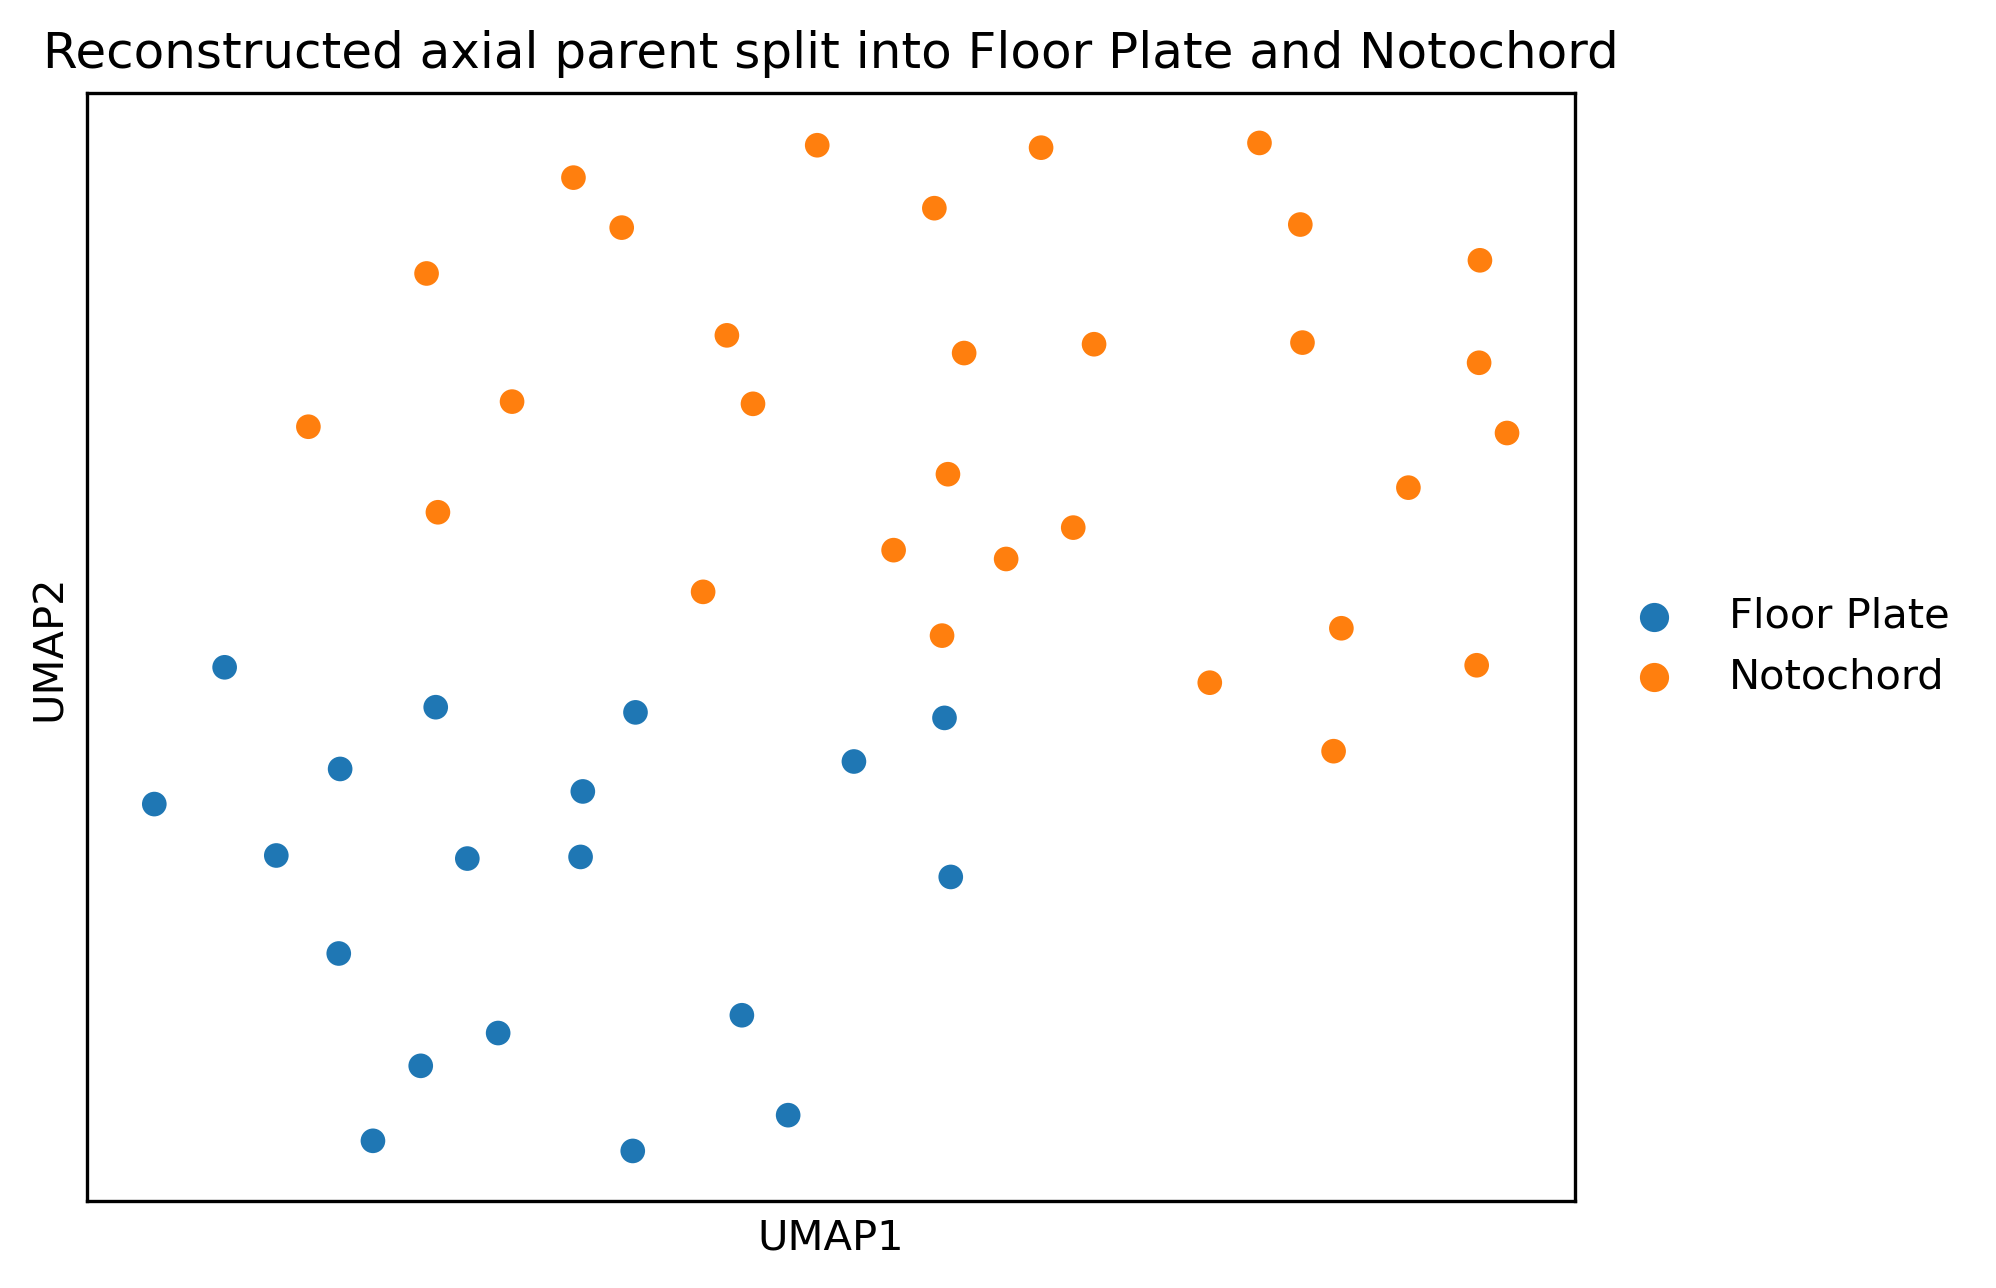

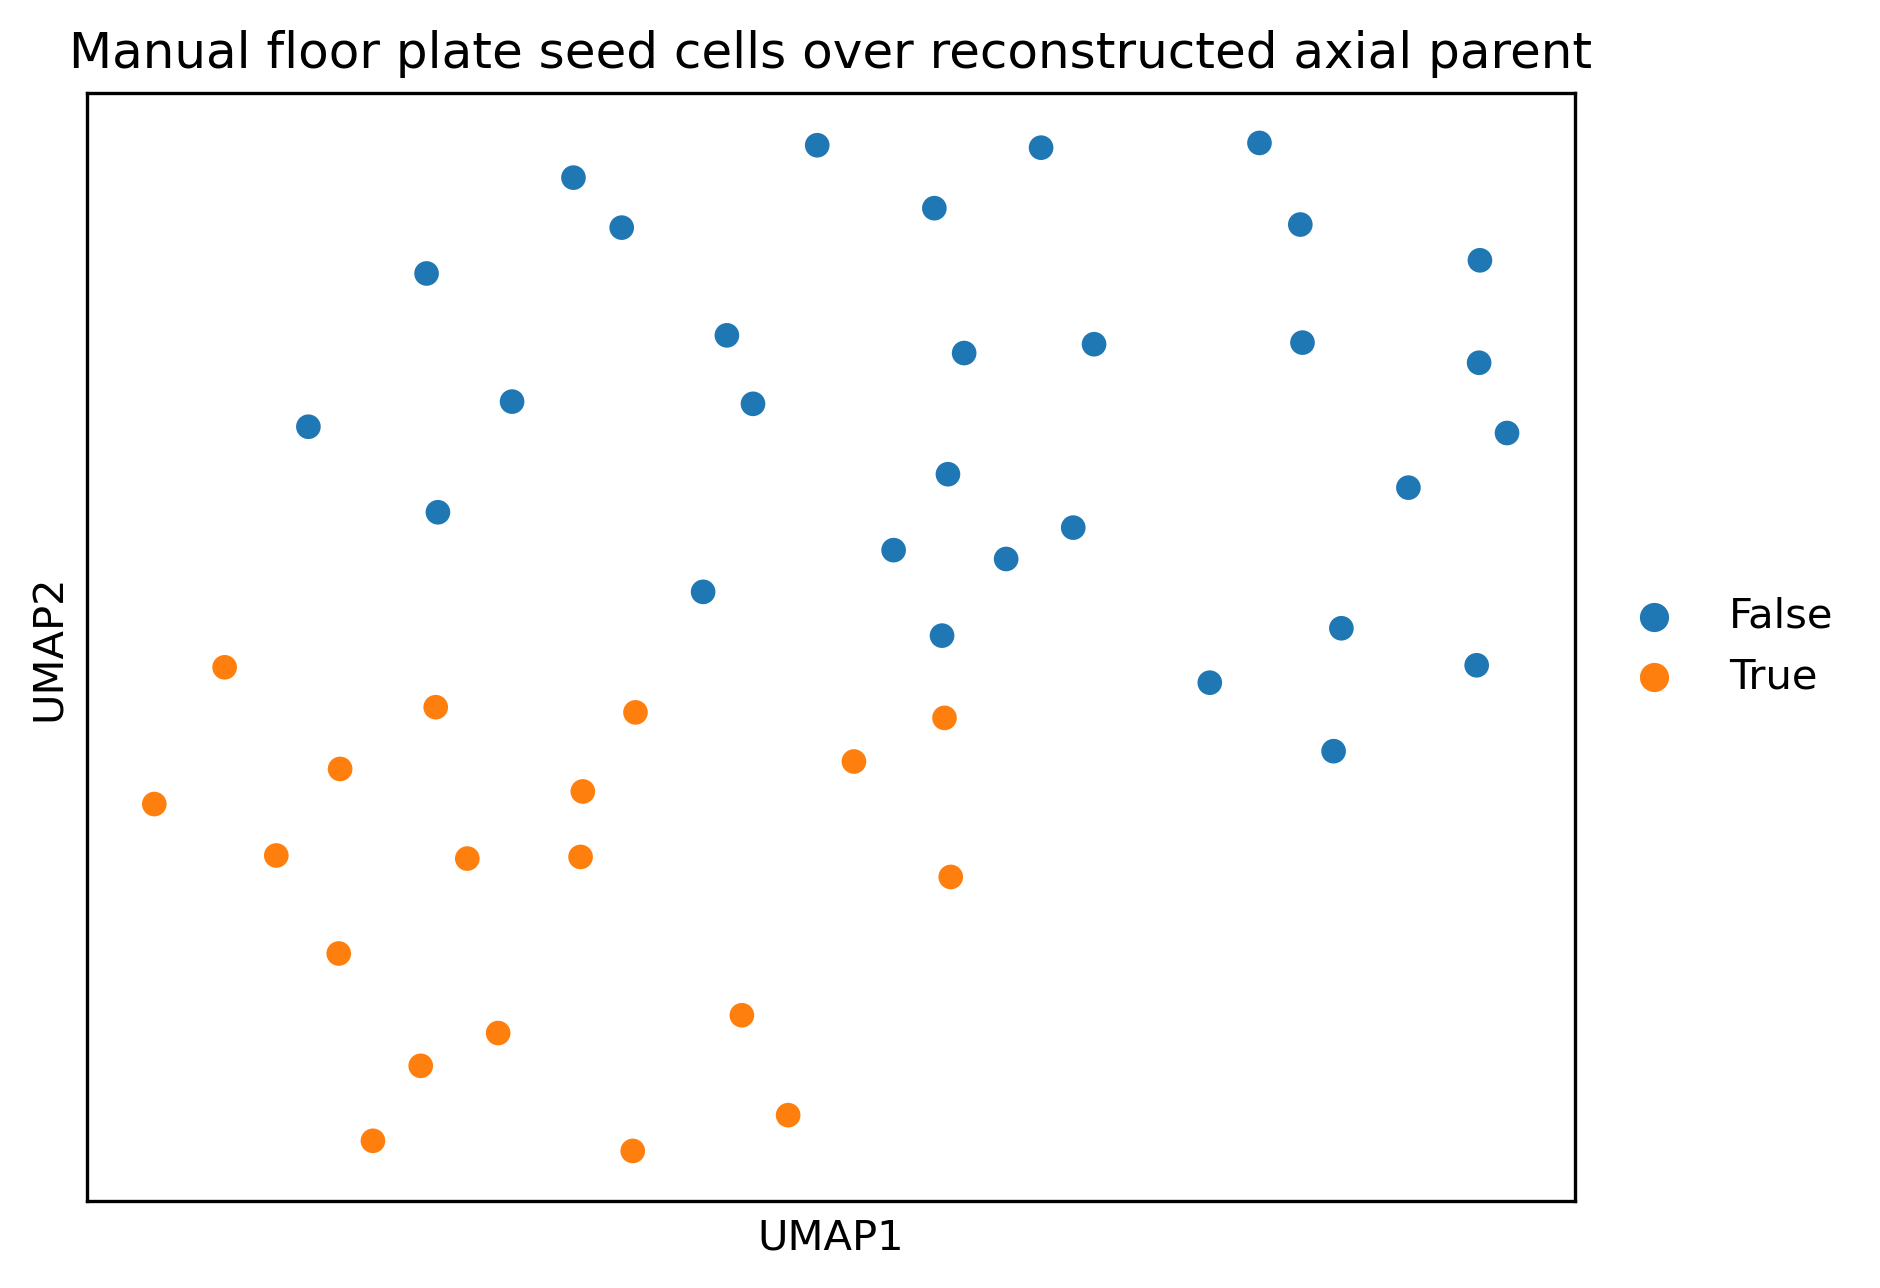

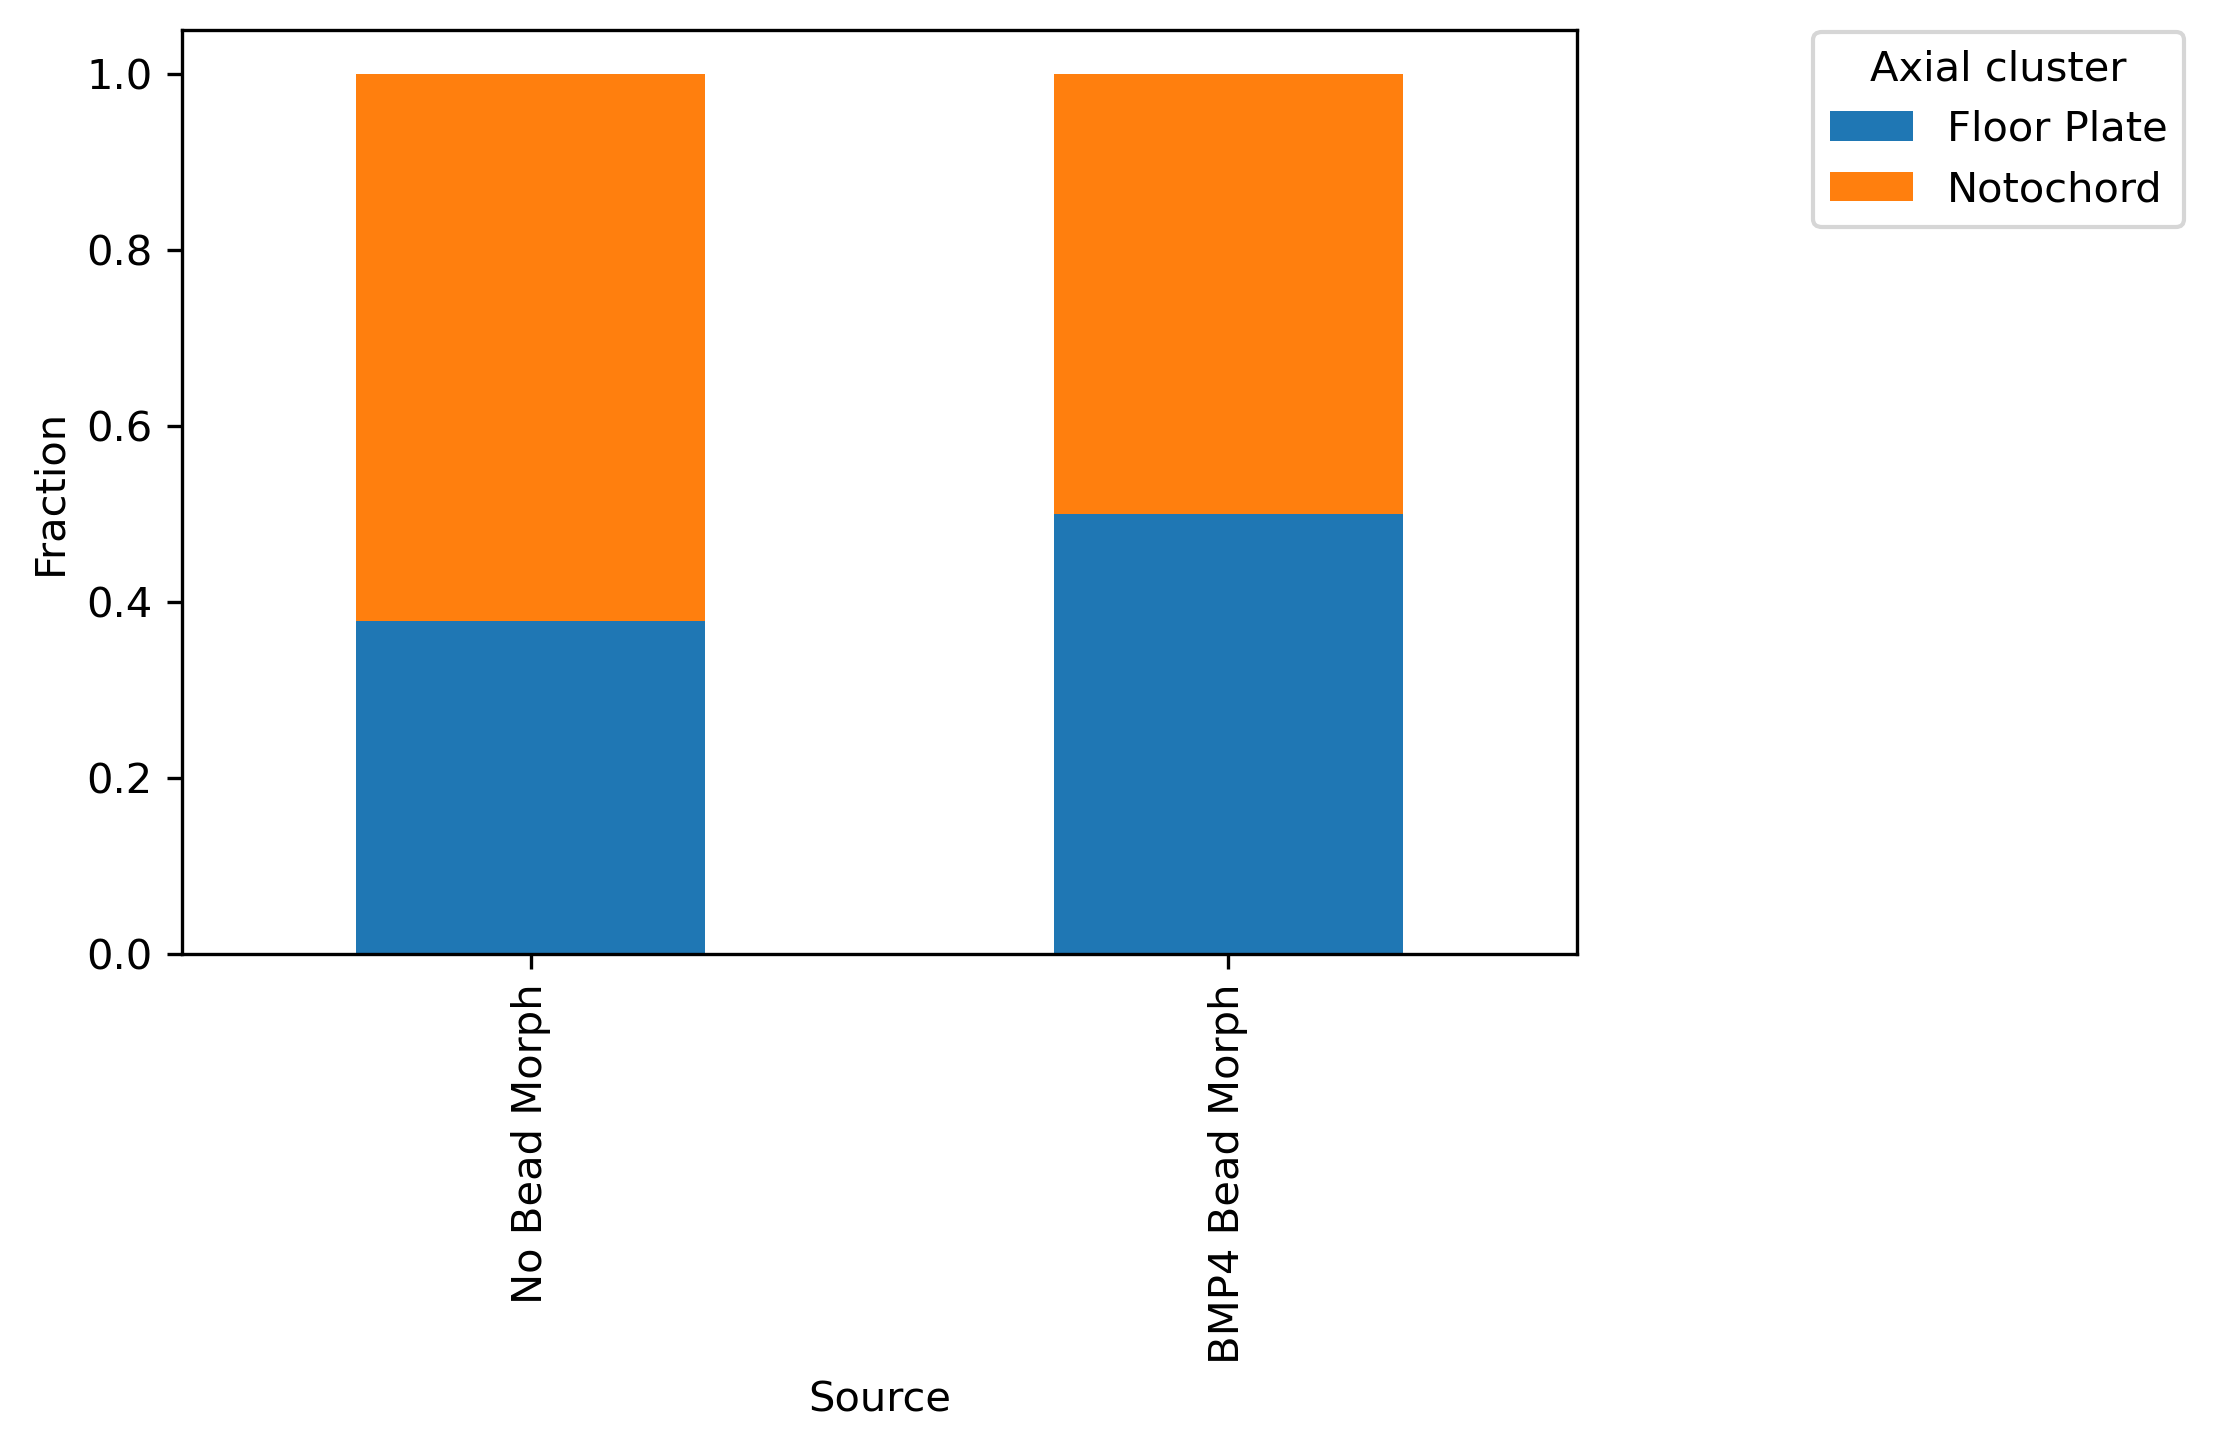

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


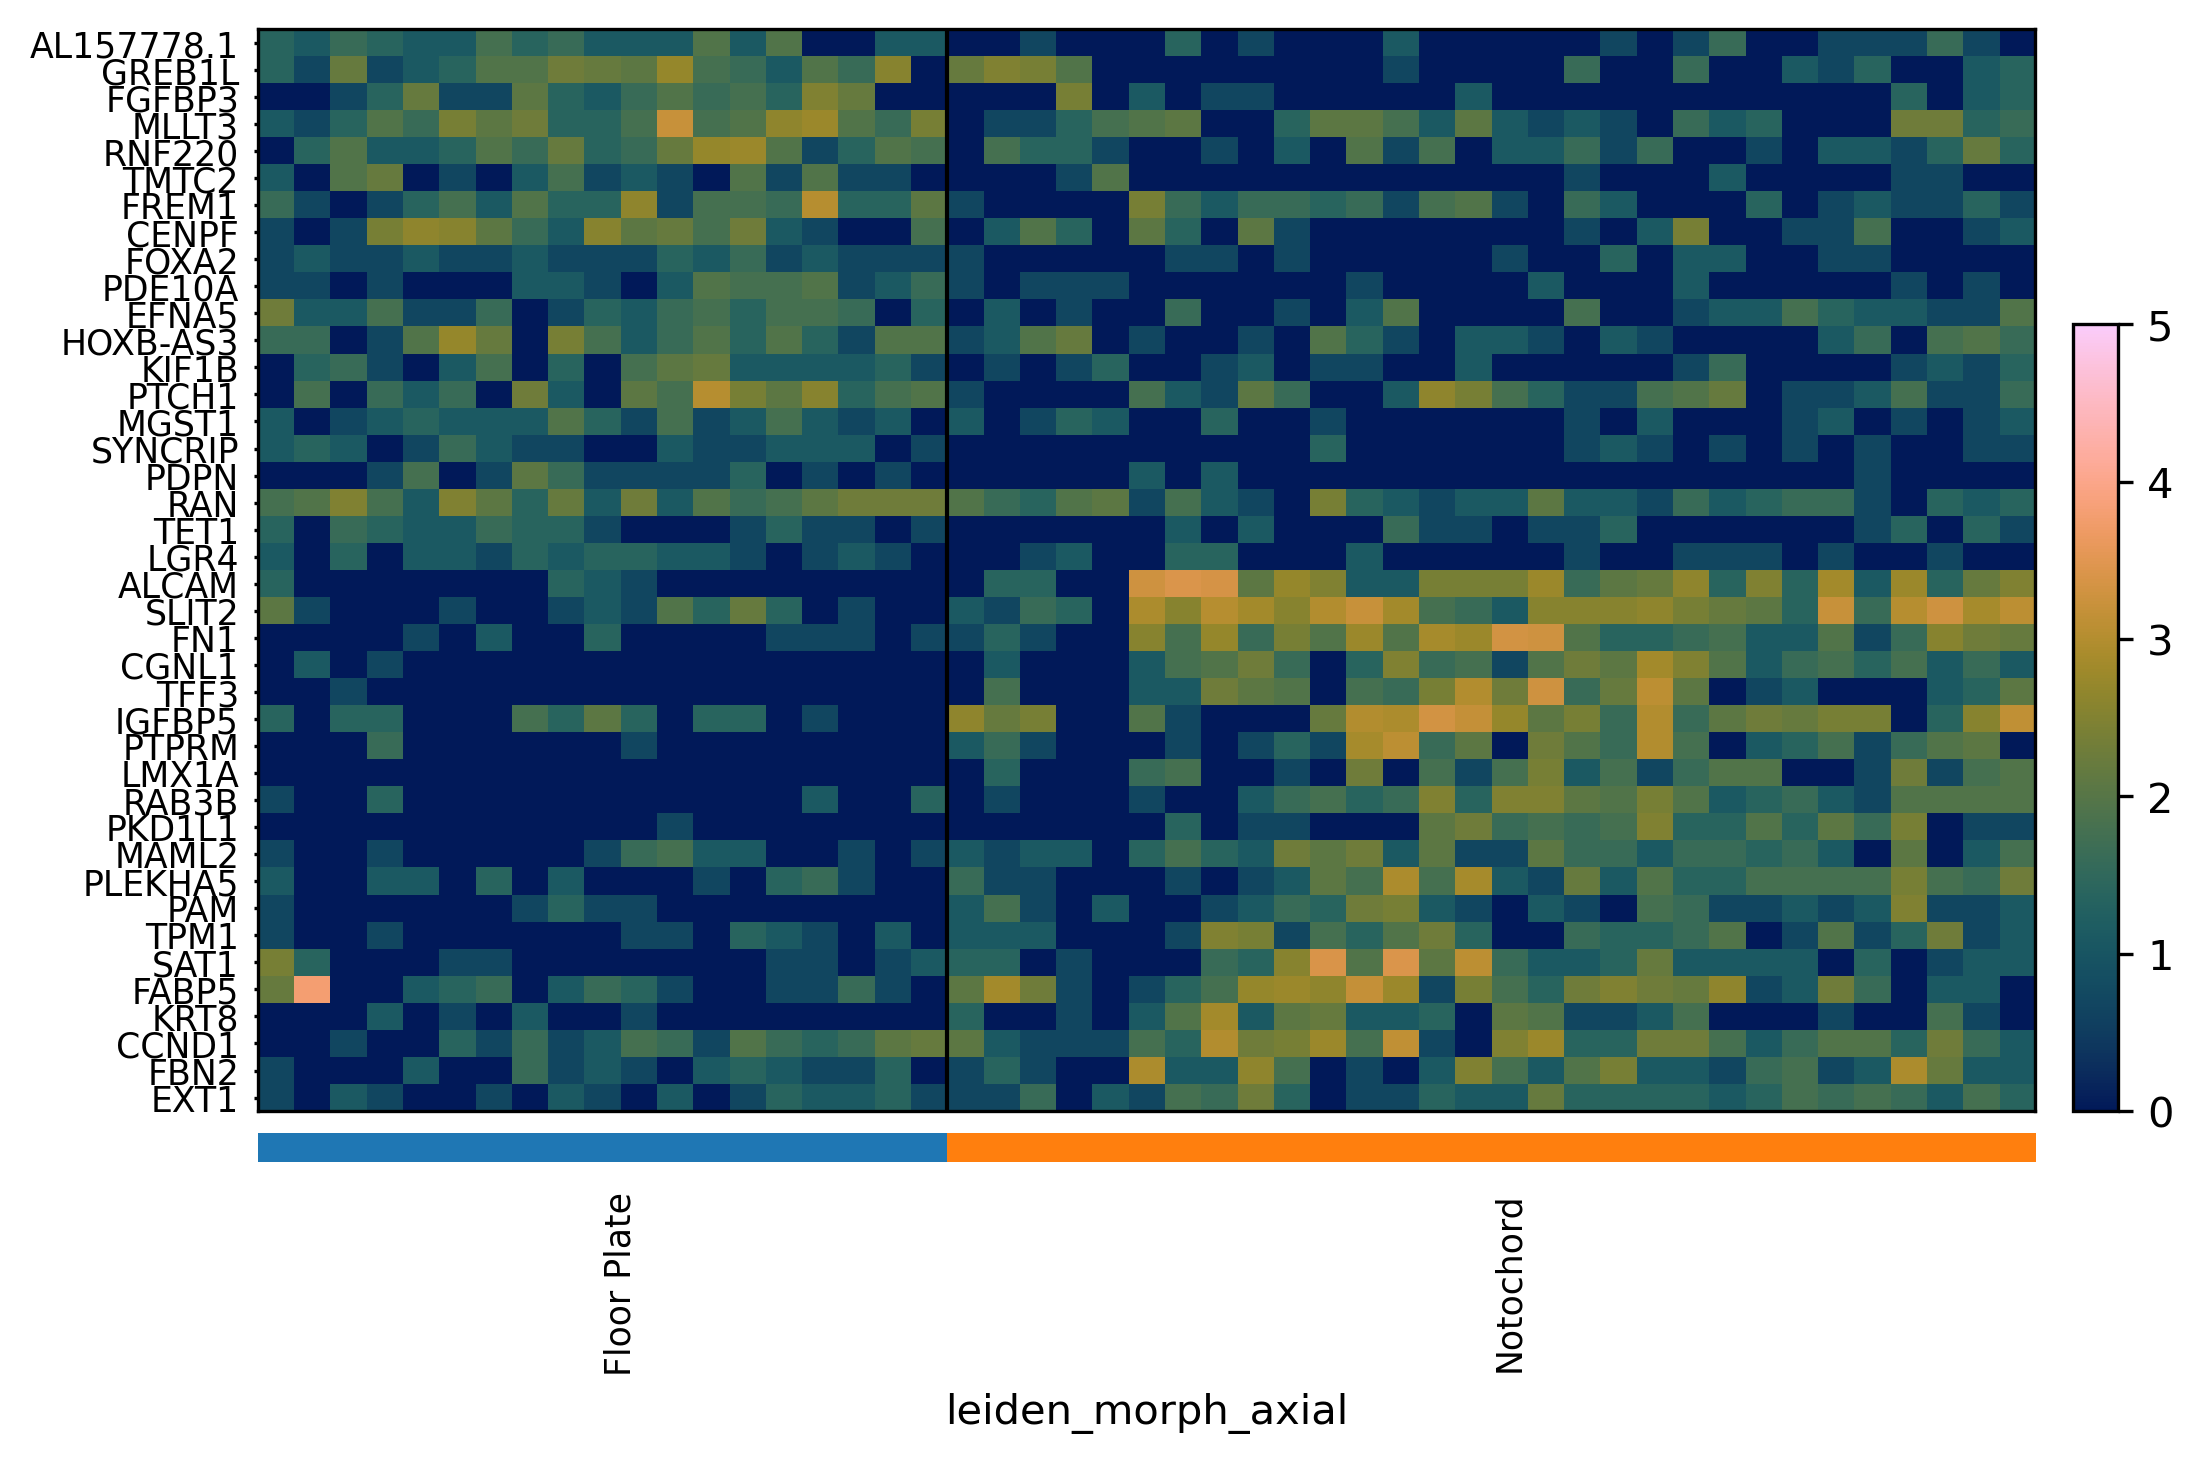

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


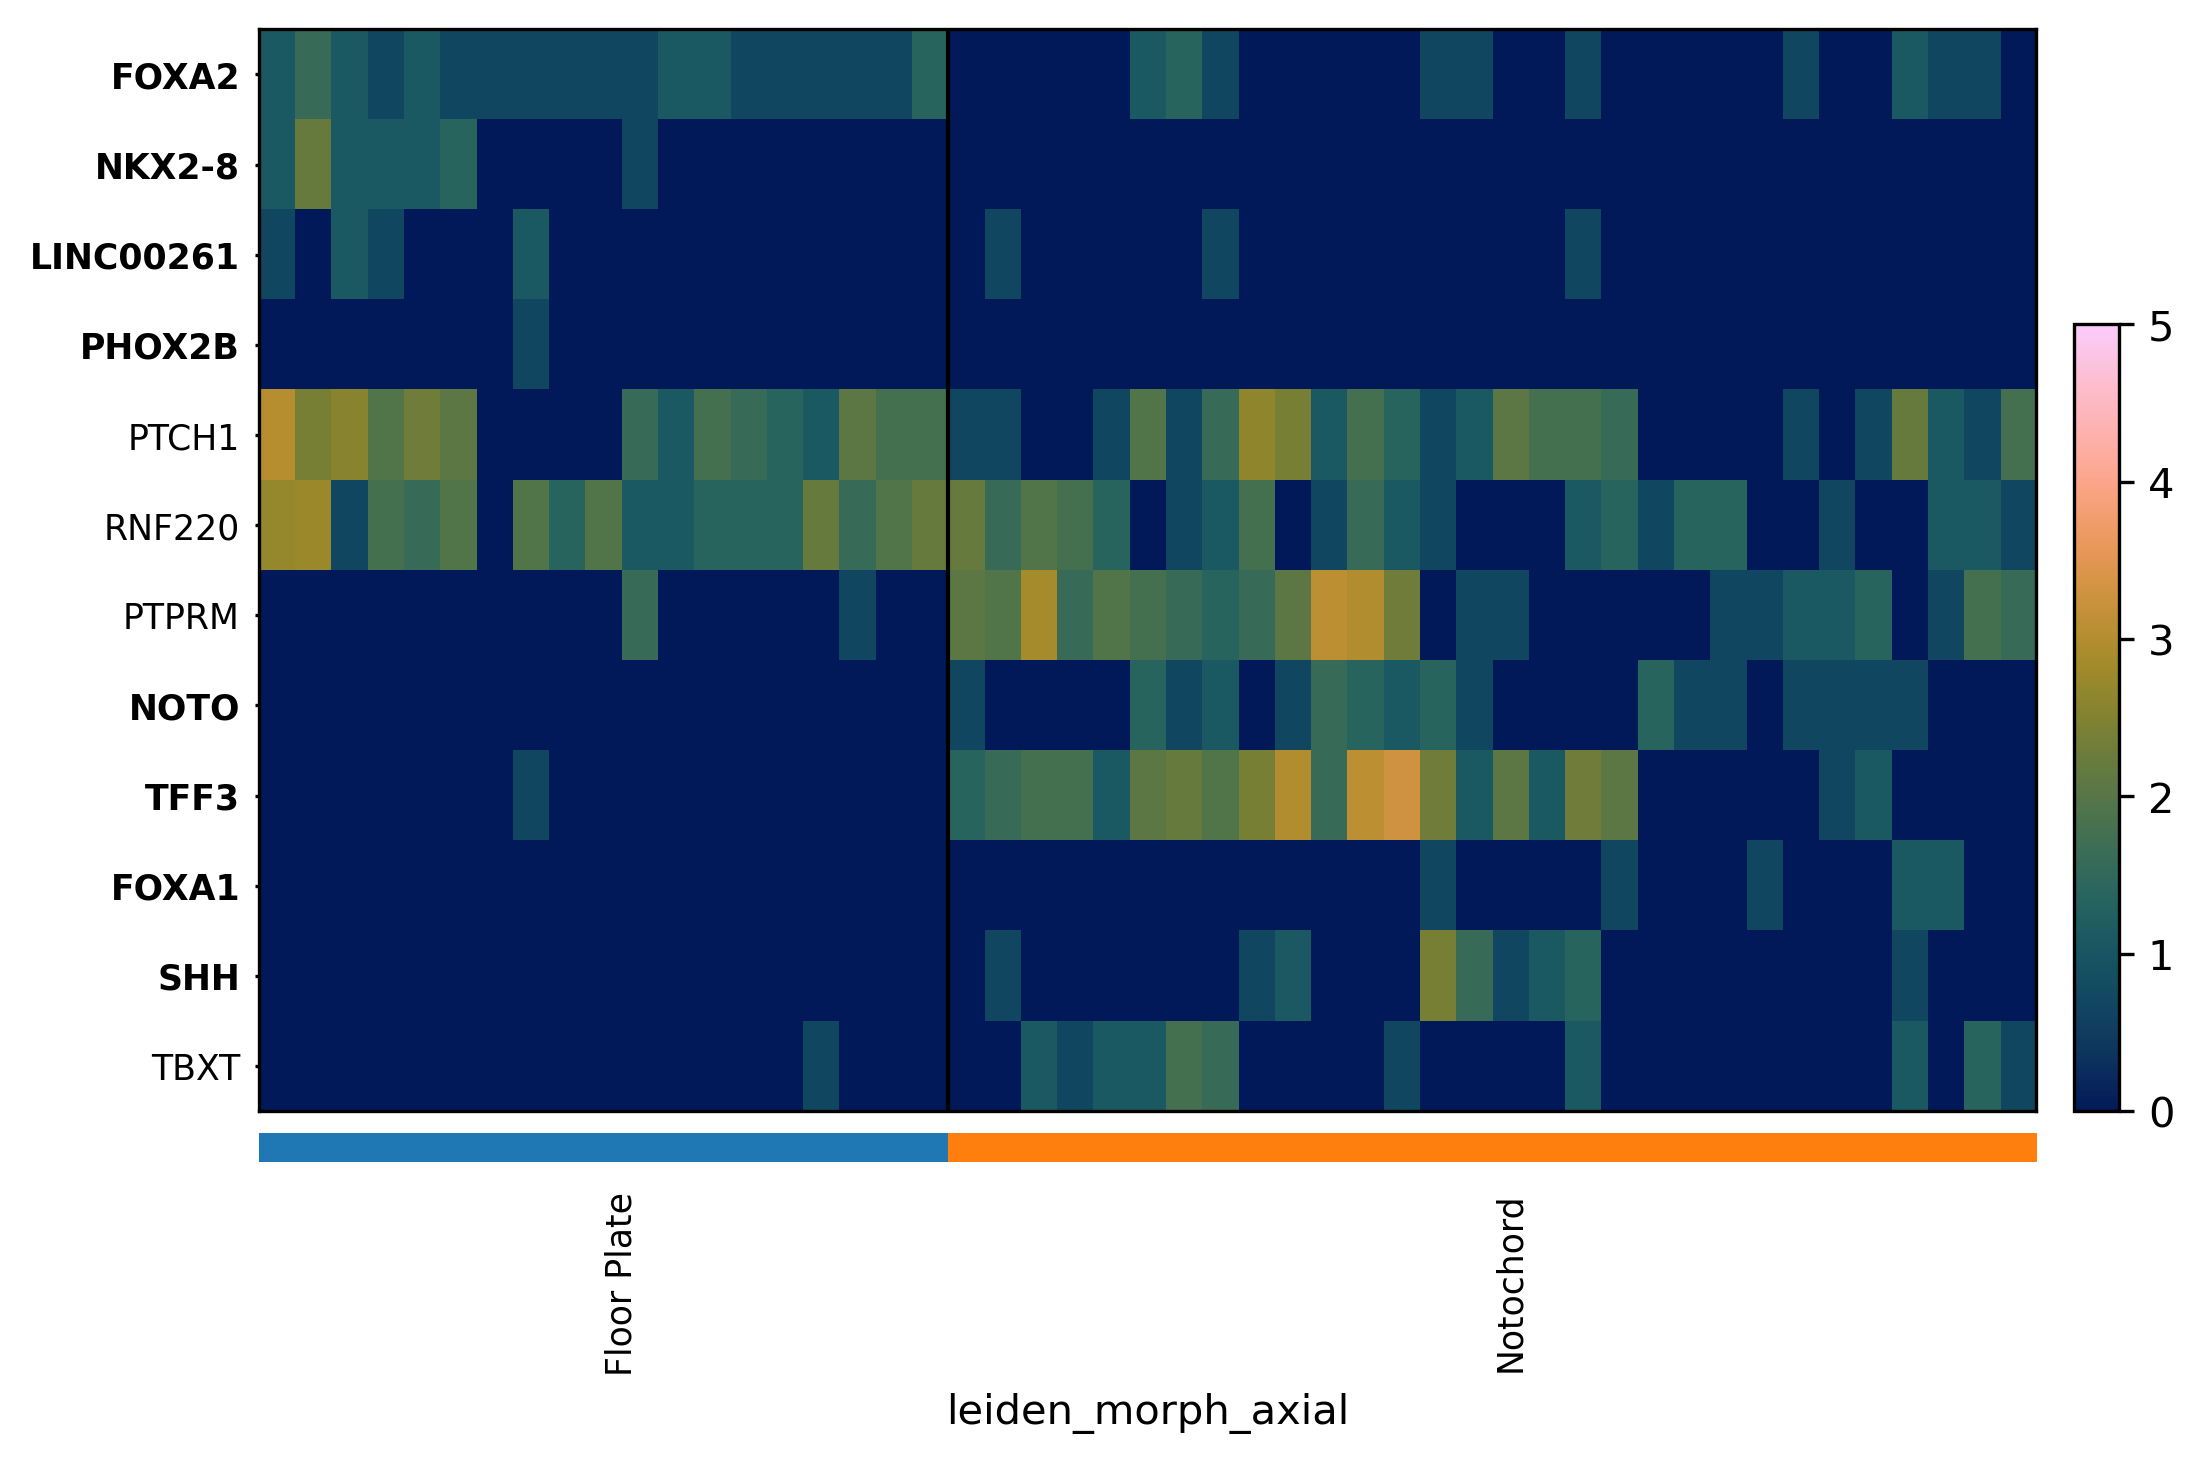

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


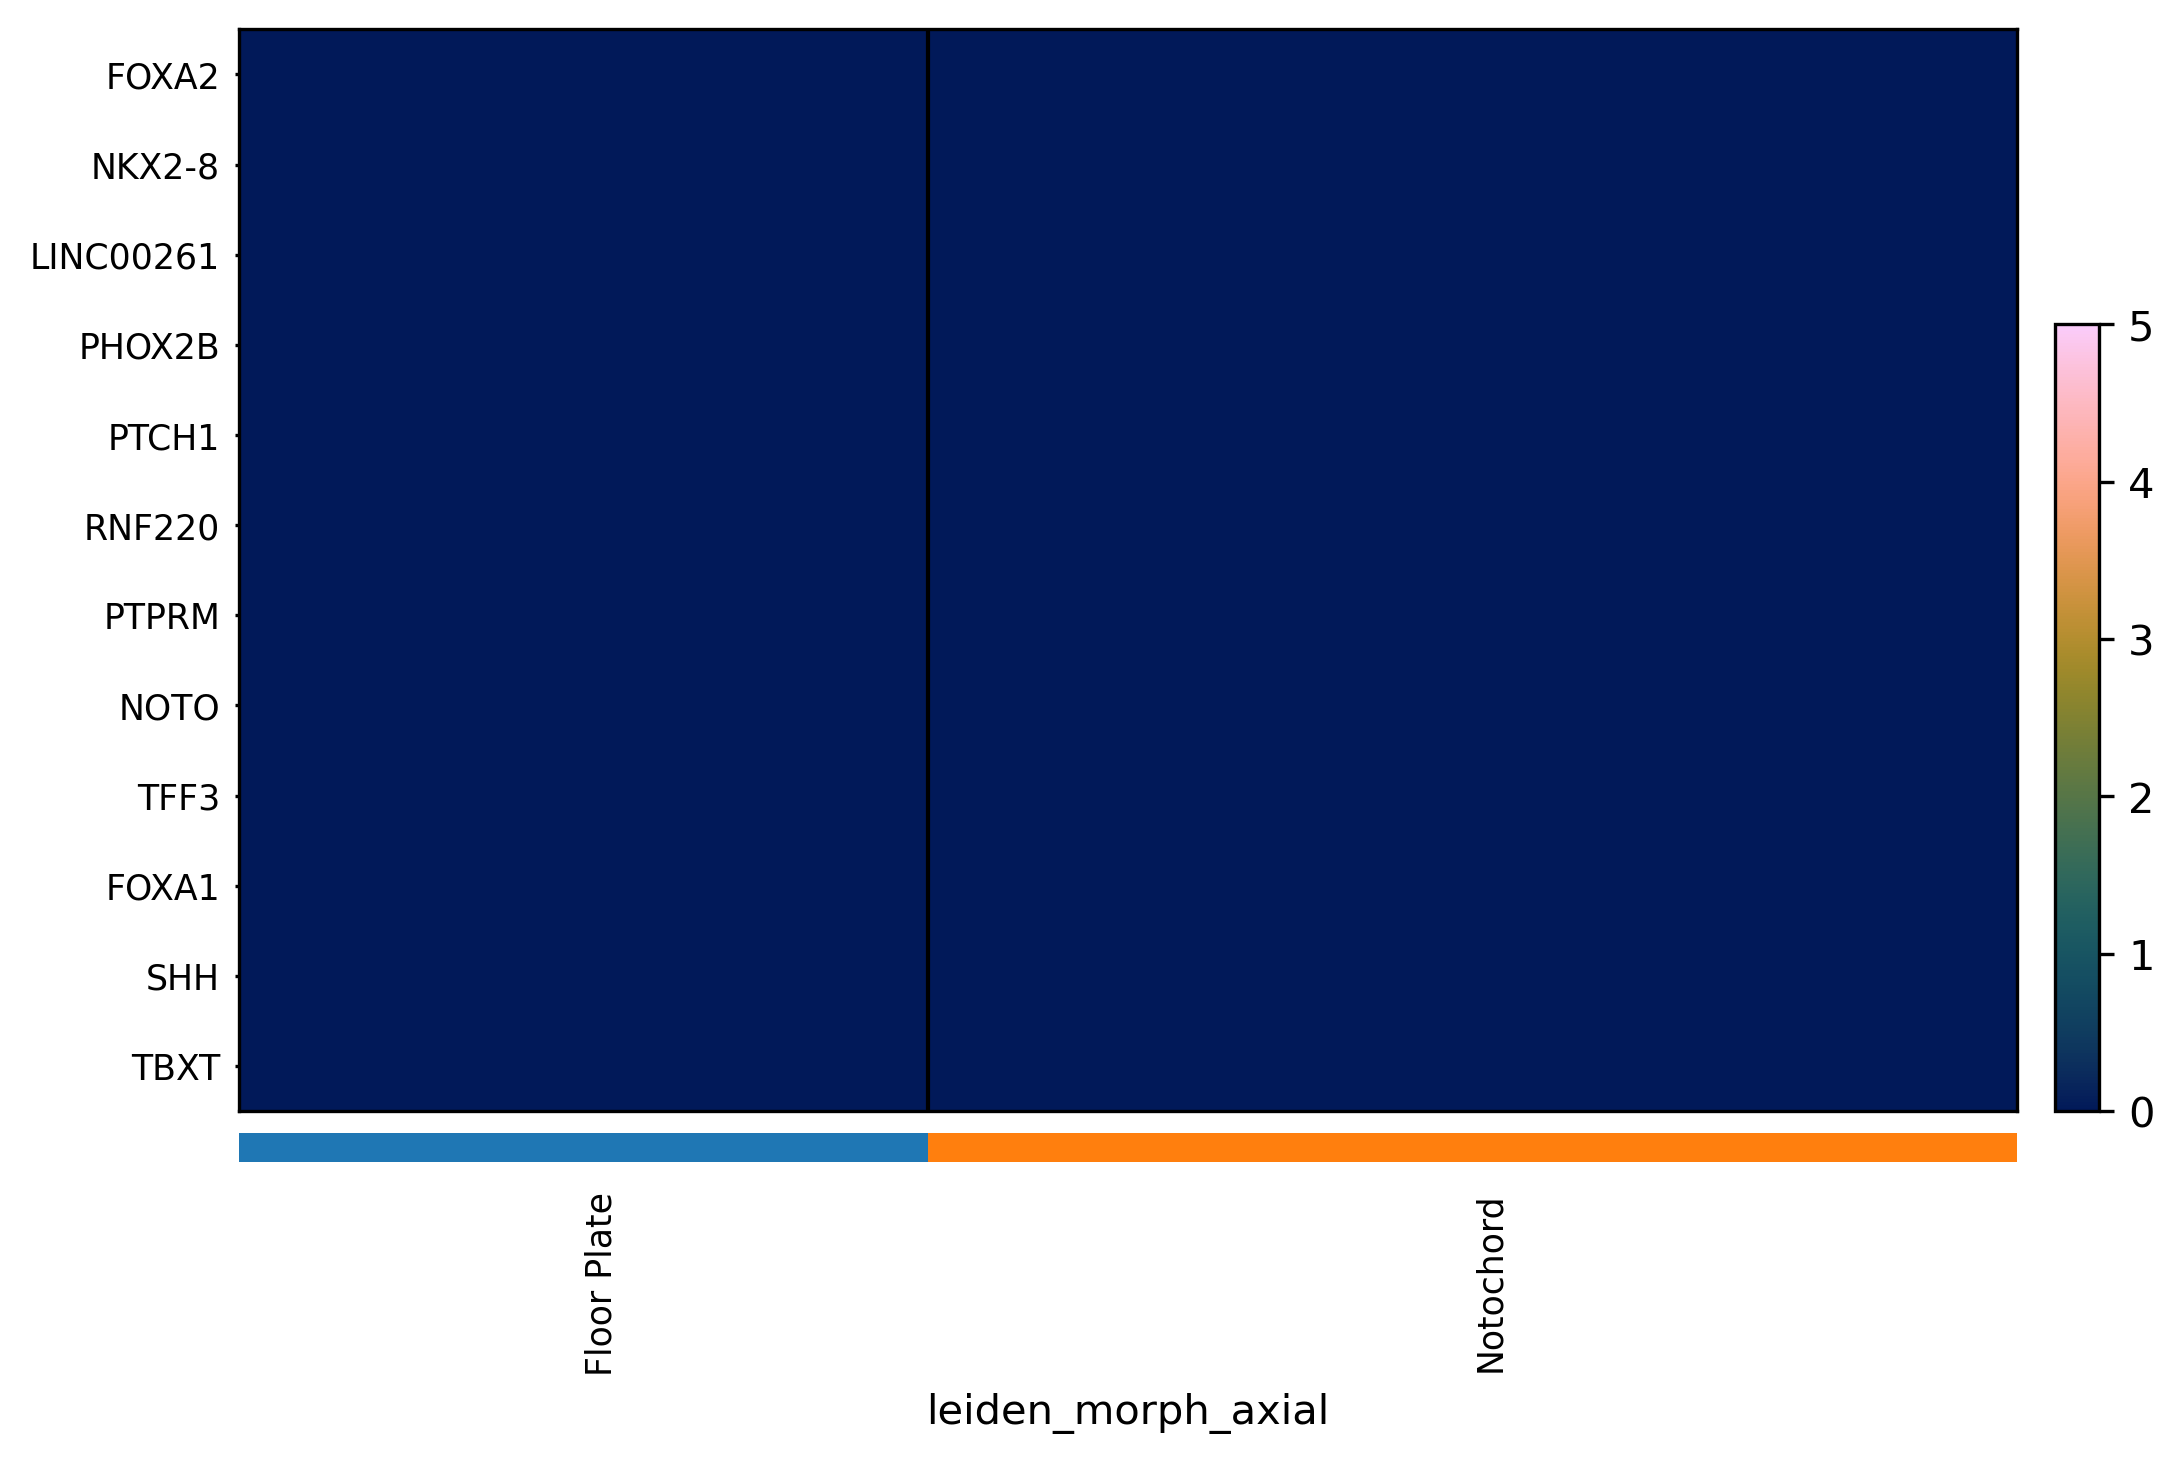

/opt/anaconda3/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2035: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


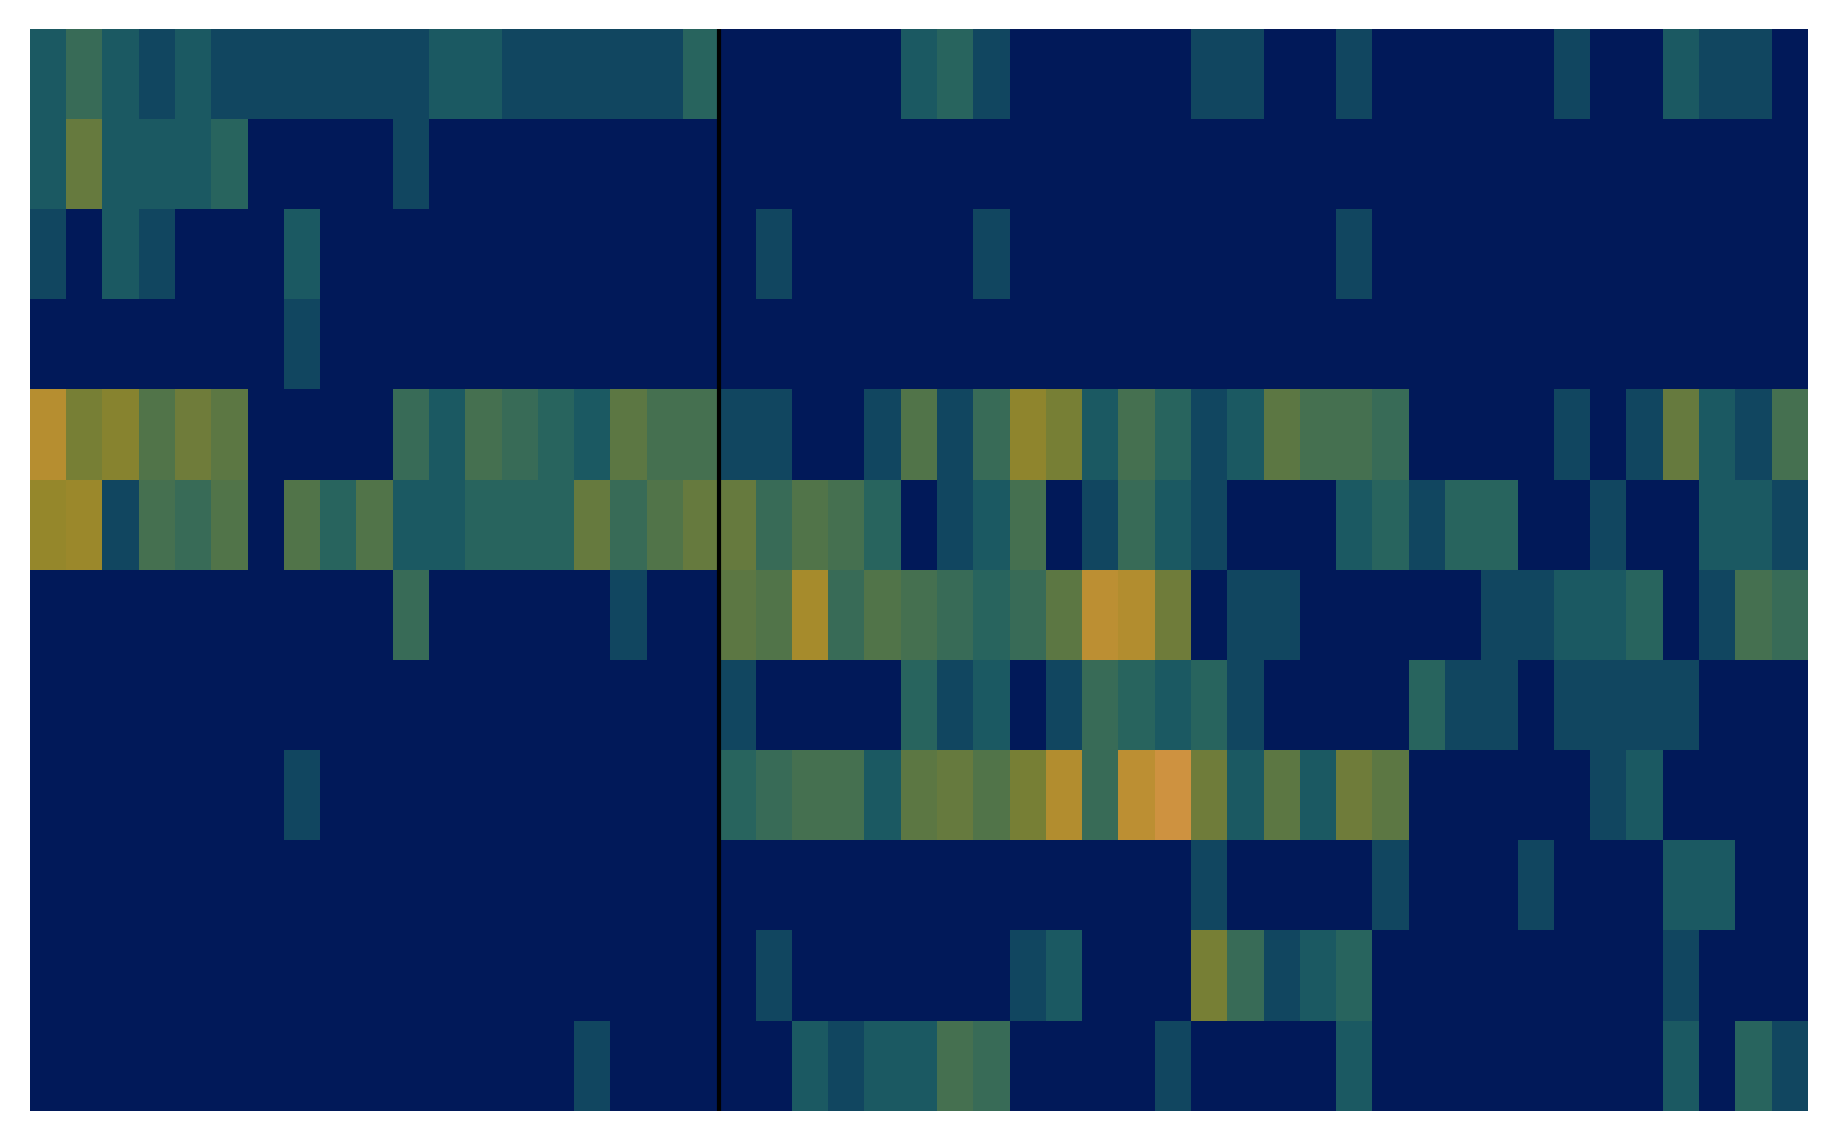

In [ ]:
celltypeorder = ['Floor Plate', 'Notochord']
for _adata in [adata_morph_axial_, adata_morph_axial_with_clusters]:
    _labels = adata_morph_axial_with_clusters.obs[LABEL_KEY].astype(str).reindex(_adata.obs_names)
    _adata.obs[LABEL_KEY] = pd.Categorical(_labels, categories=celltypeorder, ordered=True)

adata_morph_axial_panel_.obs[LABEL_KEY] = pd.Categorical(
    adata_morph_axial_panel_.obs[LABEL_KEY].astype(str),
    categories=celltypeorder,
    ordered=True,
)
adata_morph_axial_panel_ = adata_morph_axial_panel_[
    adata_morph_axial_panel_.obs[LABEL_KEY].sort_values().index, :
].copy()
adata_morph_axial_with_clusters = adata_morph_axial_with_clusters[
    adata_morph_axial_with_clusters.obs[LABEL_KEY].sort_values().index, :
].copy()

adata_morph_axial_panel_leiden = sc.get.aggregate(
    adata_morph_axial_panel_,
    by=LABEL_KEY,
    func=['count_nonzero', 'mean', 'sum', 'var'],
    axis='obs',
)
adata_morph_axial_panel_leiden.X = adata_morph_axial_panel_leiden.layers['mean']

corr_clcl_axial = np.corrcoef(adata_morph_axial_panel_leiden.layers['mean'])
cluster_clcl_axial = sns.clustermap(
    corr_clcl_axial,
    method='ward',
    metric='euclidean',
    figsize=(5, 5),
    cmap=batlow,
    yticklabels=adata_morph_axial_panel_leiden.obs[LABEL_KEY].cat.categories,
    xticklabels=adata_morph_axial_panel_leiden.obs[LABEL_KEY].cat.categories,
)
cluster_clcl_axial.fig.suptitle('Cluster-cluster mean gene correlation on the selected 06b validation panel')
cluster_clcl_axial.fig.savefig(
    figures_dir / 'noto_floor_plate_cluster_cluster_correlation.png',
    bbox_inches='tight',
    pad_inches=0,
)
cluster_clcl_axial.fig.savefig(
    figures_dir / 'noto_floor_plate_cluster_cluster_correlation.pdf',
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()
plt.close(cluster_clcl_axial.fig)

with plt.rc_context({'figure.dpi': 300}):
    sc.pl.umap(
        adata_morph_axial_panel_,
        color=LABEL_KEY,
        size=140,
        title='Reconstructed axial parent split into Floor Plate and Notochord',
        show=False,
    )
    plt.savefig(figures_dir / 'noto_floor_plate_umap_clusters.png', bbox_inches='tight', pad_inches=0)
    plt.savefig(figures_dir / 'noto_floor_plate_umap_clusters.pdf', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()
cluster_source_stackedbar = pd.crosstab(
    adata_morph_axial_with_clusters.obs['source'],
    adata_morph_axial_with_clusters.obs[LABEL_KEY],
    normalize='index',
)
cluster_source_stackedbar.to_csv(tables_dir / 'noto_floor_plate_source_stackedbar.csv')
with plt.rc_context({'figure.dpi': 300}):
    ax = cluster_source_stackedbar.plot(kind='bar', stacked=True, figsize=(6, 4))
    ax.legend(title='Axial cluster', bbox_to_anchor=(1.45, 1.02), loc='upper right')
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Source')
    plt.savefig(figures_dir / 'noto_floor_plate_stackedbar_source_composition.png', bbox_inches='tight', pad_inches=0)
    plt.savefig(figures_dir / 'noto_floor_plate_stackedbar_source_composition.pdf', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()

top_deg_per_cluster_for_heatmap = 20
heatmap_gene_ids = []
for cluster_name in celltypeorder:
    cluster_gene_ids = axial_deg_names[cluster_name].tolist()[:top_deg_per_cluster_for_heatmap]
    for gene_id in cluster_gene_ids:
        if gene_id not in heatmap_gene_ids:
            heatmap_gene_ids.append(gene_id)
pd.DataFrame(
    {
        'gene_id': heatmap_gene_ids,
        'gene_symbol': var_names_to_symbols(adata_morph_axial_with_clusters, heatmap_gene_ids),
    }
).to_csv(tables_dir / 'noto_floor_plate_deg_heatmap_gene_list.csv', index=False)

adata_axial_deg_heatmap = adata_morph_axial_with_clusters[:, heatmap_gene_ids].copy()
deg_heatmap_cell_order = ordered_cells_by_cluster_clustermap(
    adata=adata_axial_deg_heatmap,
    cluster_key=LABEL_KEY,
    var_names=adata_axial_deg_heatmap.var_names,
    figsize=(6, 6),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method='ward',
    metric='euclidean',
)
pd.DataFrame(
    {
        'cell_id': deg_heatmap_cell_order,
        LABEL_KEY: adata_morph_axial_with_clusters.obs.loc[deg_heatmap_cell_order, LABEL_KEY].astype(str).values,
    }
).to_csv(tables_dir / 'noto_floor_plate_deg_heatmap_cell_order.csv', index=False)

adata_axial_deg_heatmap = adata_axial_deg_heatmap[deg_heatmap_cell_order, heatmap_gene_ids].copy()
with plt.rc_context({'figure.dpi': 300}):
    sc.pl.heatmap(
        adata_axial_deg_heatmap,
        var_names=heatmap_gene_ids,
        groupby=LABEL_KEY,
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8, 5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    plt.savefig(figures_dir / 'noto_floor_plate_logreg_deg_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig(figures_dir / 'noto_floor_plate_logreg_deg_heatmap.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

floor_plate_deg_symbols = [
    str(adata_morph_axial_with_clusters.var.loc[gene_id, 'gene_symbol'])
    for gene_id in axial_deg_names['Floor Plate'].tolist()[:top_deg_per_cluster_for_heatmap]
]
notochord_deg_symbols = [
    str(adata_morph_axial_with_clusters.var.loc[gene_id, 'gene_symbol'])
    for gene_id in axial_deg_names['Notochord'].tolist()[:top_deg_per_cluster_for_heatmap]
]

promoted_top_symbols = []
for symbol in floor_plate_deg_symbols:
    promoted_top_symbols.append(symbol)
    if symbol == 'PDE10A' and 'NKX2-8' not in promoted_top_symbols:
        promoted_top_symbols.append('NKX2-8')
if 'PTCH1' not in promoted_top_symbols:
    promoted_top_symbols.append('PTCH1')

promoted_bottom_symbols = []
for symbol in notochord_deg_symbols:
    promoted_bottom_symbols.append(symbol)
    if symbol == 'PTPRM' and 'NOTO' not in promoted_bottom_symbols:
        promoted_bottom_symbols.append('NOTO')
    if symbol == 'LMX1A' and 'SHH' not in promoted_bottom_symbols:
        promoted_bottom_symbols.append('SHH')
    if symbol == 'PAM' and 'TBXT' not in promoted_bottom_symbols:
        promoted_bottom_symbols.append('TBXT')
for extra_symbol in ['NOTO', 'SHH', 'TBXT']:
    if extra_symbol not in promoted_bottom_symbols:
        promoted_bottom_symbols.append(extra_symbol)

promoted_key_symbols = promoted_top_symbols + promoted_bottom_symbols
promoted_key_gene_ids = []
promoted_key_gene_symbols = []
for symbol in promoted_key_symbols:
    resolved = resolve_symbols(adata_morph_axial_with_clusters, [symbol], strict=False, allow_missing=True)
    if resolved and resolved[0] not in promoted_key_gene_ids:
        promoted_key_gene_ids.append(resolved[0])
        promoted_key_gene_symbols.append(symbol)

pd.DataFrame(
    [
        {
            'gene_id': gene_id,
            'gene_symbol': gene_symbol,
            'heatmap_block': 'Floor Plate' if gene_symbol in promoted_top_symbols else 'Notochord',
        }
        for gene_id, gene_symbol in zip(promoted_key_gene_ids, promoted_key_gene_symbols)
    ]
).to_csv(tables_dir / 'noto_floor_plate_key_gene_heatmap_gene_list.csv', index=False)

adata_promoted_key_heatmap = adata_morph_axial_with_clusters[deg_heatmap_cell_order, promoted_key_gene_ids].copy()
with plt.rc_context({'figure.dpi': 300}):
    fig_dict = sc.pl.heatmap(
        adata_promoted_key_heatmap,
        var_names=promoted_key_gene_symbols,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8.5, 5.5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    keep_only_selected_heatmap_yticklabels(fig_dict, promoted_key_gene_symbols)
    bold_selected_heatmap_yticklabels(fig_dict, PROMOTED_KEY_HEATMAP_BOLD)
    plt.savefig(figures_dir / 'noto_floor_plate_key_gene_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig(figures_dir / 'noto_floor_plate_key_gene_heatmap.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

with plt.rc_context({'figure.dpi': 300}):
    plot_empty_heatmap_axes(
        adata_promoted_key_heatmap,
        var_names=promoted_key_gene_ids,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8.5, 5.5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    plt.savefig(figures_dir / 'noto_floor_plate_key_gene_heatmap_axesonly.svg', bbox_inches='tight', pad_inches=0)
    plt.savefig(figures_dir / 'noto_floor_plate_key_gene_heatmap_axesonly.pdf', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()

with plt.rc_context({'figure.dpi': 300}):
    fig_dict = sc.pl.heatmap(
        adata_promoted_key_heatmap,
        var_names=promoted_key_gene_symbols,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8.5, 5.5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    hide_heatmap_axes_and_colorbar(fig_dict)
    plt.savefig(figures_dir / 'noto_floor_plate_key_gene_heatmap_noaxes.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()

manual_marker_gene_ids = []
for symbol in MANUAL_MARKER_HEATMAP_MARKERS:
    resolved = resolve_symbols(adata_morph_axial_with_clusters, [symbol], strict=False, allow_missing=True)
    if resolved and resolved[0] not in manual_marker_gene_ids:
        manual_marker_gene_ids.append(resolved[0])

adata_axial_marker_heatmap = adata_morph_axial_with_clusters[:, manual_marker_gene_ids].copy()
marker_heatmap_cell_order = ordered_cells_by_cluster_clustermap(
    adata=adata_axial_marker_heatmap,
    cluster_key=LABEL_KEY,
    var_names=adata_axial_marker_heatmap.var_names,
    figsize=(6, 6),
    vmin=0,
    vmax=5,
    cmap=batlow,
    method='ward',
    metric='euclidean',
)
pd.DataFrame(
    {
        'cell_id': marker_heatmap_cell_order,
        LABEL_KEY: adata_morph_axial_with_clusters.obs.loc[marker_heatmap_cell_order, LABEL_KEY].astype(str).values,
        'manual_floor_plate_seed': adata_morph_axial_with_clusters.obs.loc[marker_heatmap_cell_order, 'manual_floor_plate_seed'].astype(bool).values,
    }
).to_csv(tables_dir / 'noto_floor_plate_marker_heatmap_cell_order.csv', index=False)

manual_marker_gene_symbols = var_names_to_symbols(adata_morph_axial_with_clusters, manual_marker_gene_ids)
pd.DataFrame(
    {
        'gene_id': manual_marker_gene_ids,
        'gene_symbol': manual_marker_gene_symbols,
    }
).to_csv(tables_dir / 'noto_floor_plate_manual_marker_heatmap_gene_list.csv', index=False)

adata_axial_marker_heatmap = adata_axial_marker_heatmap[marker_heatmap_cell_order, manual_marker_gene_ids].copy()
with plt.rc_context({'figure.dpi': 300}):
    fig_dict = sc.pl.heatmap(
        adata_axial_marker_heatmap,
        var_names=manual_marker_gene_symbols,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8, 5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    keep_only_selected_heatmap_yticklabels(fig_dict, manual_marker_gene_symbols)
    bold_selected_heatmap_yticklabels(fig_dict, MANUAL_MARKER_HEATMAP_BOLD)
    plt.savefig(figures_dir / 'noto_floor_plate_manual_marker_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig(figures_dir / 'noto_floor_plate_manual_marker_heatmap.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

with plt.rc_context({'figure.dpi': 300}):
    plot_empty_heatmap_axes(
        adata_axial_marker_heatmap,
        var_names=manual_marker_gene_ids,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8, 5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    plt.savefig(figures_dir / 'noto_floor_plate_manual_marker_heatmap_axesonly.svg', bbox_inches='tight', pad_inches=0)
    plt.savefig(figures_dir / 'noto_floor_plate_manual_marker_heatmap_axesonly.pdf', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()

with plt.rc_context({'figure.dpi': 300}):
    fig_dict = sc.pl.heatmap(
        adata_axial_marker_heatmap,
        var_names=manual_marker_gene_symbols,
        groupby=LABEL_KEY,
        gene_symbols='gene_symbol',
        swap_axes=True,
        show_gene_labels=True,
        figsize=(8, 5),
        cmap=batlow,
        vmin=0,
        vmax=5,
        dendrogram=False,
        show=False,
    )
    hide_heatmap_axes_and_colorbar(fig_dict)
    plt.savefig(figures_dir / 'noto_floor_plate_manual_marker_heatmap_noaxes.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    plt.close()


## Save Completed `06b` Outputs

In [ ]:
for _adata in [adata_morph_axial_, adata_morph_axial_filtered_, adata_morph_axial_panel, adata_morph_axial_panel_, adata_morph_axial_with_clusters]:
    assert_gene_id_index(_adata)

save_h5ad(adata_morph_axial_, stage_path / 'adata_morph_notochord_floor_plate_.h5ad')
save_h5ad(adata_morph_axial_filtered_, stage_path / 'adata_morph_notochord_floor_plate_filtered_.h5ad')
save_h5ad(adata_morph_axial_panel, stage_path / 'adata_morph_notochord_floor_plate_panel.h5ad')
save_h5ad(adata_morph_axial_panel_, stage_path / 'adata_morph_notochord_floor_plate_panel_.h5ad')
save_h5ad(adata_morph_axial_with_clusters, stage_path / 'adata_morph_notochord_floor_plate_with_clusters.h5ad')

# Keep legacy filenames in sync for any older downstream readers that still expect the SMD names.
save_h5ad(adata_morph_axial_panel, stage_path / 'adata_morph_notochord_floor_plate_SMD.h5ad')
save_h5ad(adata_morph_axial_panel_, stage_path / 'adata_morph_notochord_floor_plate_SMD_.h5ad')

adata_morph_axial_with_clusters.obs[
    ['leiden_morph', 'manual_floor_plate_seed', RAW_LABEL_KEY, LABEL_KEY]
].to_csv(tables_dir / 'noto_floor_plate_cluster_labels.csv')

meta = {
    'stage': STAGE_ID,
    'status': 'validation_complete',
    'upstream_stage': '02_trunk_main',
    'parent_clusters_reconstructed_from_02': axial_clusters,
    'parent_cluster_note': 'Current Floor Plate plus Notochord labels reconstruct the original coarse Notochord / Floor Plate population from 02.',
    'n_parent_cluster_cells': int(adata_morph_axial_.n_obs),
    'n_preprocessed_genes': int(adata_morph_axial_filtered_.n_vars),
    'manual_validation_gene_panel': manual_panel_genes,
    'n_selected_panel_genes': int(adata_morph_axial_panel.n_vars),
    'panel_gene_table': 'tables/noto_floor_plate_selected_panel_genes.csv',
    'gene_selection_rule': 'manual_validation_panel_only_after_cell_cycle_exclusion',
    'resolution_scan_values': SCAN_RESOLUTIONS,
    'neighbor_graph_method': 'scanpy default neighbors on the selected 06b manual validation panel',
    'chosen_leiden_resolution': CHOSEN_LEIDEN_RESOLUTION,
    'chosen_leiden_reason': CHOSEN_LEIDEN_REASON,
    'raw_cluster_key': RAW_LABEL_KEY,
    'raw_cluster_labels': list(adata_morph_axial_with_clusters.obs[RAW_LABEL_KEY].cat.categories),
    'floor_plate_raw_cluster': floor_plate_raw_cluster,
    'cluster_key': LABEL_KEY,
    'cluster_labels': list(adata_morph_axial_with_clusters.obs[LABEL_KEY].cat.categories),
    'floor_plate_cluster_name': 'Floor Plate',
    'notochord_cluster_name': 'Notochord',
    'manual_floor_plate_seed_cell_count': int(adata_morph_axial_with_clusters.obs['manual_floor_plate_seed'].sum()),
    'seed_validation_table': 'tables/noto_floor_plate_seed_validation.csv',
    'figures_dir': 'figures',
    'tables_dir': 'tables',
}
save_json(meta, stage_path / 'meta.json')
print(f'Saved completed 06b validation outputs to {stage_path}')
print(f"Final split: {adata_morph_axial_with_clusters.obs[LABEL_KEY].astype(str).value_counts().to_dict()}")


Saved completed 06b outputs to <analysis-root>/trunk_main_dev/results/intermediates/06b_notochord_floor_plate_subclustering
